In [294]:
!pip install numpy pandas

Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: python3.10 -m pip install --upgrade pip


In [295]:
ls

 241AI030.py     'Preprocessing (1).ipynb'   SDNFlow_Dataset_Normal.csv
'Paper (1).pdf'   Preprocessing.ipynb        SDNFlow_Dataset.zip
 Paper.pdf        SDNFlow_Dataset/           search_lab.py


In [296]:
import numpy as np
import pandas as pd

### Data Preprocessing

In [297]:
df = pd.read_csv('SDNFlow_Dataset_Normal.csv')

In [298]:
df.head()

,flow_ID,eth_type,ipv4_src,ipv4_dst,ip_proto,src_port,dst_port,flow_duration,tot_len_pkts,tot_pkts,...,idle_std,TnBPDstIP,TnBPSrcIP,TnPPDstIP,TnPPSrcIP,TnPPerDport,Tn_FlowsPDstIP,Tn_FlowsPSrcIP,Attack,Category
0,1,2048,192.168.56.201,192.168.56.1,6,22,41410,6.472,113472,628,...,0.0,113472,7295988,628,6659,628,1,10,0,SSH
1,2,2048,192.168.56.1,192.168.56.201,6,41410,22,6.465,24492,370,...,0.0,26080,24492,381,370,370,2,1,0,SSH
2,3,2048,192.168.56.203,192.168.56.201,1,0,0,4.798,2211,4,...,0.0,28291,3799,385,15,0,3,2,0,ICMP
3,4,2048,192.168.56.201,192.168.56.203,17,57426,1236,595.270,10827817,25627,...,0.0,188960322,180776253,157117,153898,30743,60,19,0,STREAMING
4,5,2048,192.168.56.201,192.168.56.203,17,48549,1234,595.251,154551644,114704,...,0.0,188960322,180776253,157117,153898,122654,60,19,0,STREAMING


In [299]:
df.shape

(221564, 39)

In [300]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 221564 entries, 0 to 221563
Data columns (total 39 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   flow_ID                221564 non-null  int64  
 1   eth_type               221564 non-null  int64  
 2   ipv4_src               221564 non-null  object 
 3   ipv4_dst               221564 non-null  object 
 4   ip_proto               221564 non-null  int64  
 5   src_port               221564 non-null  int64  
 6   dst_port               221564 non-null  int64  
 7   flow_duration          221564 non-null  float64
 8   tot_len_pkts           221564 non-null  int64  
 9   tot_pkts               221564 non-null  int64  
 10  flow_byts_s            221564 non-null  float64
 11  flow_pkts_s            221564 non-null  float64
 12  pkt_size_average       221564 non-null  float64
 13  fwd_header_len         221564 non-null  int64  
 14  Byts_max_interval_2s   221564 non-nu

In [301]:
df.isnull().sum()

flow_ID                  0
eth_type                 0
ipv4_src                 0
ipv4_dst                 0
ip_proto                 0
src_port                 0
dst_port                 0
flow_duration            0
tot_len_pkts             0
tot_pkts                 0
flow_byts_s              0
flow_pkts_s              0
pkt_size_average         0
fwd_header_len           0
Byts_max_interval_2s     0
Byts_min_interval_2s     0
Byts_mean_interval_2s    0
Byts_std_interval_2s     0
Pkts_max_interval_2s     0
Pkts_mean_interval_2s    0
Pkts_min_interval_2s     0
Pkts_std_interval_2s     0
active_max               0
active_mean              0
active_min               0
active_std               0
idle_max                 0
idle_mean                0
idle_min                 0
idle_std                 0
TnBPDstIP                0
TnBPSrcIP                0
TnPPDstIP                0
TnPPSrcIP                0
TnPPerDport              0
Tn_FlowsPDstIP           0
Tn_FlowsPSrcIP           0
A

In [302]:
df['Category'].unique()

array(['SSH', 'ICMP', 'STREAMING', 'DNS', 'HTTP', 'FTP', 'NTP'],
      dtype=object)

In [303]:


df['eth_type'].unique().size


1

drop eth_type

In [304]:
df['ipv4_src'].unique().size

3083

In [305]:
to_drop = []
for i in df.columns:
    counts = df[i].unique().size
    print(f"{i} size : {counts}")
    if counts == 1:
        to_drop.append(i)

flow_ID size : 221564
eth_type size : 1
ipv4_src size : 3083
ipv4_dst size : 3115
ip_proto size : 3
src_port size : 22369
dst_port size : 21964
flow_duration size : 18047
tot_len_pkts size : 16118
tot_pkts size : 1118
flow_byts_s size : 105626
flow_pkts_s size : 53855
pkt_size_average size : 28509
fwd_header_len size : 1239
Byts_max_interval_2s size : 14111
Byts_min_interval_2s size : 9050
Byts_mean_interval_2s size : 25389
Byts_std_interval_2s size : 26875
Pkts_max_interval_2s size : 867
Pkts_mean_interval_2s size : 2768
Pkts_min_interval_2s size : 403
Pkts_std_interval_2s size : 6976
active_max size : 89
active_mean size : 250
active_min size : 78
active_std size : 264
idle_max size : 10
idle_mean size : 322
idle_min size : 10
idle_std size : 491
TnBPDstIP size : 22390
TnBPSrcIP size : 24957
TnPPDstIP size : 8239
TnPPSrcIP size : 4399
TnPPerDport size : 3373
Tn_FlowsPDstIP size : 201
Tn_FlowsPSrcIP size : 223
Attack size : 1
Category size : 7


In [306]:
to_drop

['eth_type', 'Attack']

In [307]:
!pip install scikit-learn

Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: python3.10 -m pip install --upgrade pip


In [308]:
# from sklearn.preprocessing import OneHotEncoder

In [309]:
# ohe = OneHotEncoder()

In [310]:
from sklearn.preprocessing import LabelEncoder

In [311]:
le_catg = LabelEncoder()

In [312]:
df['Category'] = le_catg .fit_transform(df['Category'])


In [313]:
df.head()

,flow_ID,eth_type,ipv4_src,ipv4_dst,ip_proto,src_port,dst_port,flow_duration,tot_len_pkts,tot_pkts,...,idle_std,TnBPDstIP,TnBPSrcIP,TnPPDstIP,TnPPSrcIP,TnPPerDport,Tn_FlowsPDstIP,Tn_FlowsPSrcIP,Attack,Category
0,1,2048,192.168.56.201,192.168.56.1,6,22,41410,6.472,113472,628,...,0.0,113472,7295988,628,6659,628,1,10,0,5
1,2,2048,192.168.56.1,192.168.56.201,6,41410,22,6.465,24492,370,...,0.0,26080,24492,381,370,370,2,1,0,5
2,3,2048,192.168.56.203,192.168.56.201,1,0,0,4.798,2211,4,...,0.0,28291,3799,385,15,0,3,2,0,3
3,4,2048,192.168.56.201,192.168.56.203,17,57426,1236,595.270,10827817,25627,...,0.0,188960322,180776253,157117,153898,30743,60,19,0,6
4,5,2048,192.168.56.201,192.168.56.203,17,48549,1234,595.251,154551644,114704,...,0.0,188960322,180776253,157117,153898,122654,60,19,0,6


In [314]:
le_catg .classes_

array(['DNS', 'FTP', 'HTTP', 'ICMP', 'NTP', 'SSH', 'STREAMING'],
      dtype=object)

In [315]:
mapping_catg = dict(zip(le_catg .classes_,le_catg .transform(le_catg .classes_)))

In [316]:
le_catg .transform(['HTTP'])

array([2])

In [317]:
mapping_catg

{'DNS': 0, 'FTP': 1, 'HTTP': 2, 'ICMP': 3, 'NTP': 4, 'SSH': 5, 'STREAMING': 6}

In [318]:
df.head(-5)

,flow_ID,eth_type,ipv4_src,ipv4_dst,ip_proto,src_port,dst_port,flow_duration,tot_len_pkts,tot_pkts,...,idle_std,TnBPDstIP,TnBPSrcIP,TnPPDstIP,TnPPSrcIP,TnPPerDport,Tn_FlowsPDstIP,Tn_FlowsPSrcIP,Attack,Category
0,1,2048,192.168.56.201,192.168.56.1,6,22,41410,6.472,113472,628,...,0.0,113472,7295988,628,6659,628,1,10,0,5
1,2,2048,192.168.56.1,192.168.56.201,6,41410,22,6.465,24492,370,...,0.0,26080,24492,381,370,370,2,1,0,5
2,3,2048,192.168.56.203,192.168.56.201,1,0,0,4.798,2211,4,...,0.0,28291,3799,385,15,0,3,2,0,3
3,4,2048,192.168.56.201,192.168.56.203,17,57426,1236,595.270,10827817,25627,...,0.0,188960322,180776253,157117,153898,30743,60,19,0,6
4,5,2048,192.168.56.201,192.168.56.203,17,48549,1234,595.251,154551644,114704,...,0.0,188960322,180776253,157117,153898,122654,60,19,0,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
221554,221555,2048,8.43.72.98,192.168.56.203,6,443,46158,0.114,0,0,...,0.0,162706107,0,136042,0,0,161,3,0,2
221555,221556,2048,192.168.56.203,200.24.19.252,17,36103,53,0.320,77,1,...,0.0,4172,197595,27,1967,5,32,152,0,0
221556,221557,2048,200.24.19.252,192.168.56.203,17,53,36103,1.290,374,2,...,0.0,163711889,6183,136965,38,2,158,31,0,0
221557,221558,2048,192.168.56.203,200.24.19.252,17,39597,53,0.669,0,0,...,0.0,4172,197595,27,1967,5,32,152,0,0


In [319]:
df2 = df.copy()
le_src = LabelEncoder()
le_dst = LabelEncoder()


In [320]:
df2['ipv4_src'] = le_src .fit_transform(df2['ipv4_src'])
df2['ipv4_dst'] = le_dst .fit_transform(df2['ipv4_dst'])


In [321]:
mapping_src  = dict(zip(le_src .classes_,le_src .transform(le_src .classes_)))


In [322]:
mapping_dest = dict(zip(le_dst .classes_,le_dst .transform(le_dst .classes_)))

In [323]:
df2.head()

,flow_ID,eth_type,ipv4_src,ipv4_dst,ip_proto,src_port,dst_port,flow_duration,tot_len_pkts,tot_pkts,...,idle_std,TnBPDstIP,TnBPSrcIP,TnPPDstIP,TnPPSrcIP,TnPPerDport,Tn_FlowsPDstIP,Tn_FlowsPSrcIP,Attack,Category
0,1,2048,1484,1499,6,22,41410,6.472,113472,628,...,0.0,113472,7295988,628,6659,628,1,10,0,5
1,2,2048,1482,1501,6,41410,22,6.465,24492,370,...,0.0,26080,24492,381,370,370,2,1,0,5
2,3,2048,1486,1501,1,0,0,4.798,2211,4,...,0.0,28291,3799,385,15,0,3,2,0,3
3,4,2048,1484,1503,17,57426,1236,595.270,10827817,25627,...,0.0,188960322,180776253,157117,153898,30743,60,19,0,6
4,5,2048,1484,1503,17,48549,1234,595.251,154551644,114704,...,0.0,188960322,180776253,157117,153898,122654,60,19,0,6


In [324]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 221564 entries, 0 to 221563
Data columns (total 39 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   flow_ID                221564 non-null  int64  
 1   eth_type               221564 non-null  int64  
 2   ipv4_src               221564 non-null  int64  
 3   ipv4_dst               221564 non-null  int64  
 4   ip_proto               221564 non-null  int64  
 5   src_port               221564 non-null  int64  
 6   dst_port               221564 non-null  int64  
 7   flow_duration          221564 non-null  float64
 8   tot_len_pkts           221564 non-null  int64  
 9   tot_pkts               221564 non-null  int64  
 10  flow_byts_s            221564 non-null  float64
 11  flow_pkts_s            221564 non-null  float64
 12  pkt_size_average       221564 non-null  float64
 13  fwd_header_len         221564 non-null  int64  
 14  Byts_max_interval_2s   221564 non-nu

## Visualize

In [325]:
import matplotlib.pyplot as plt
import seaborn as sns

## Preprocessing

In [326]:
from sklearn.preprocessing import StandardScaler , RobustScaler, MinMaxScaler

In [327]:
## dropping flow_ID
df2.drop("flow_ID",axis = 1,inplace=True)
#Removing eth_type
df2 = df2.drop('eth_type',axis=1)

target = "Category"
num_cols = df2.select_dtypes(include=['int64','float64']).columns.drop(target, errors='ignore')
# cat_cols = df.select_dtypes(include=['object']).columns

In [328]:
df2.head()

,ipv4_src,ipv4_dst,ip_proto,src_port,dst_port,flow_duration,tot_len_pkts,tot_pkts,flow_byts_s,flow_pkts_s,...,idle_std,TnBPDstIP,TnBPSrcIP,TnPPDstIP,TnPPSrcIP,TnPPerDport,Tn_FlowsPDstIP,Tn_FlowsPSrcIP,Attack,Category
0,1484,1499,6,22,41410,6.472,113472,628,17532.756490,97.033375,...,0.0,113472,7295988,628,6659,628,1,10,0,5
1,1482,1501,6,41410,22,6.465,24492,370,3788.399072,57.231245,...,0.0,26080,24492,381,370,370,2,1,0,5
2,1486,1501,1,0,0,4.798,2211,4,460.817007,0.833681,...,0.0,28291,3799,385,15,0,3,2,0,3
3,1484,1503,17,57426,1236,595.270,10827817,25627,18189.757590,43.051052,...,0.0,188960322,180776253,157117,153898,30743,60,19,0,6
4,1484,1503,17,48549,1234,595.251,154551644,114704,259641.132900,192.698542,...,0.0,188960322,180776253,157117,153898,122654,60,19,0,6


In [329]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 221564 entries, 0 to 221563
Data columns (total 37 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   ipv4_src               221564 non-null  int64  
 1   ipv4_dst               221564 non-null  int64  
 2   ip_proto               221564 non-null  int64  
 3   src_port               221564 non-null  int64  
 4   dst_port               221564 non-null  int64  
 5   flow_duration          221564 non-null  float64
 6   tot_len_pkts           221564 non-null  int64  
 7   tot_pkts               221564 non-null  int64  
 8   flow_byts_s            221564 non-null  float64
 9   flow_pkts_s            221564 non-null  float64
 10  pkt_size_average       221564 non-null  float64
 11  fwd_header_len         221564 non-null  int64  
 12  Byts_max_interval_2s   221564 non-null  int64  
 13  Byts_min_interval_2s   221564 non-null  int64  
 14  Byts_mean_interval_2s  221564 non-nu

In [330]:
num_cols

Index(['ipv4_src', 'ipv4_dst', 'ip_proto', 'src_port', 'dst_port',
       'flow_duration', 'tot_len_pkts', 'tot_pkts', 'flow_byts_s',
       'flow_pkts_s', 'pkt_size_average', 'fwd_header_len',
       'Byts_max_interval_2s', 'Byts_min_interval_2s', 'Byts_mean_interval_2s',
       'Byts_std_interval_2s', 'Pkts_max_interval_2s', 'Pkts_mean_interval_2s',
       'Pkts_min_interval_2s', 'Pkts_std_interval_2s', 'active_max',
       'active_mean', 'active_min', 'active_std', 'idle_max', 'idle_mean',
       'idle_min', 'idle_std', 'TnBPDstIP', 'TnBPSrcIP', 'TnPPDstIP',
       'TnPPSrcIP', 'TnPPerDport', 'Tn_FlowsPDstIP', 'Tn_FlowsPSrcIP',
       'Attack'],
      dtype='object')

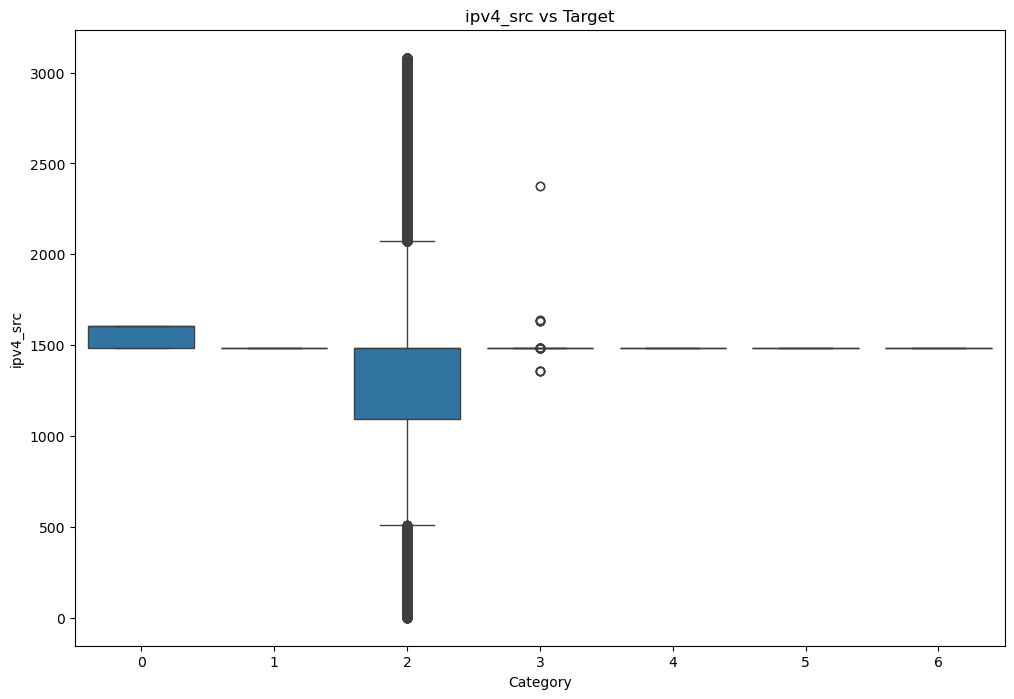

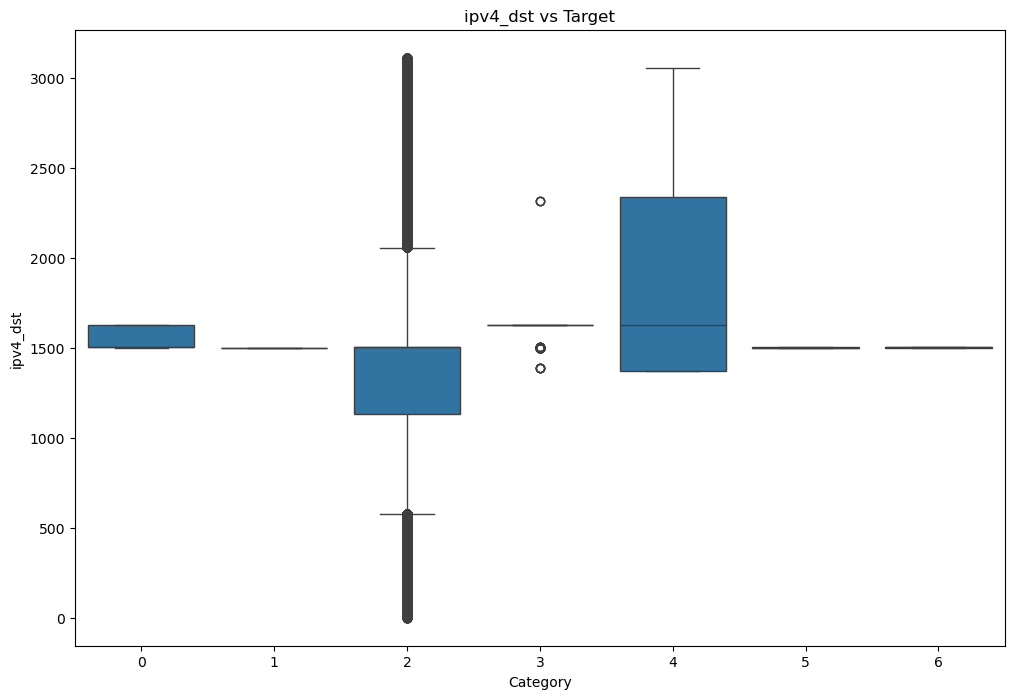

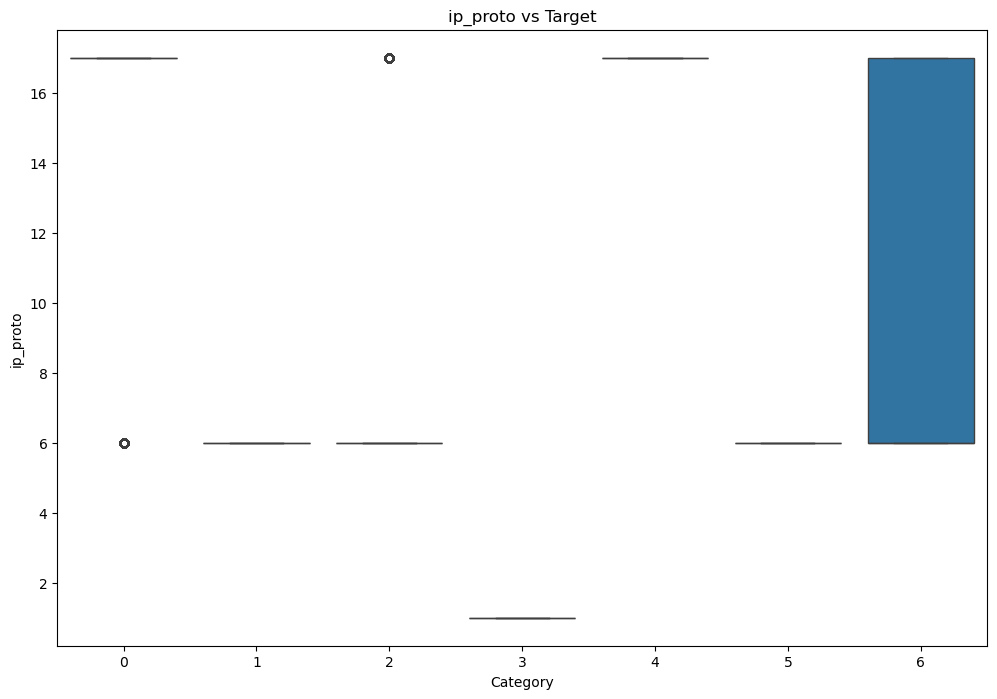

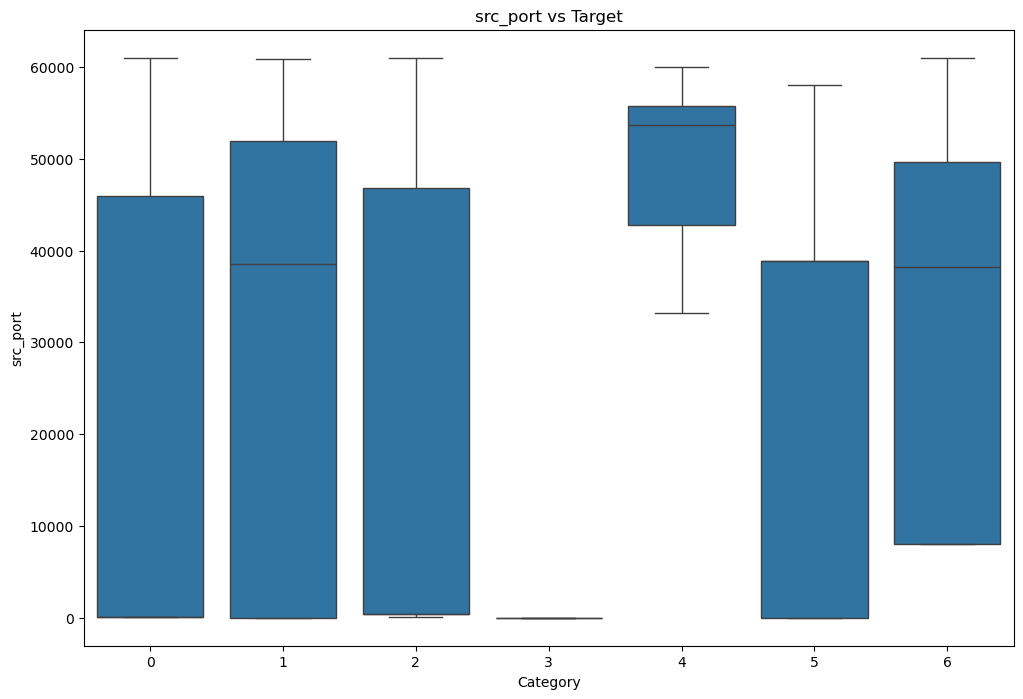

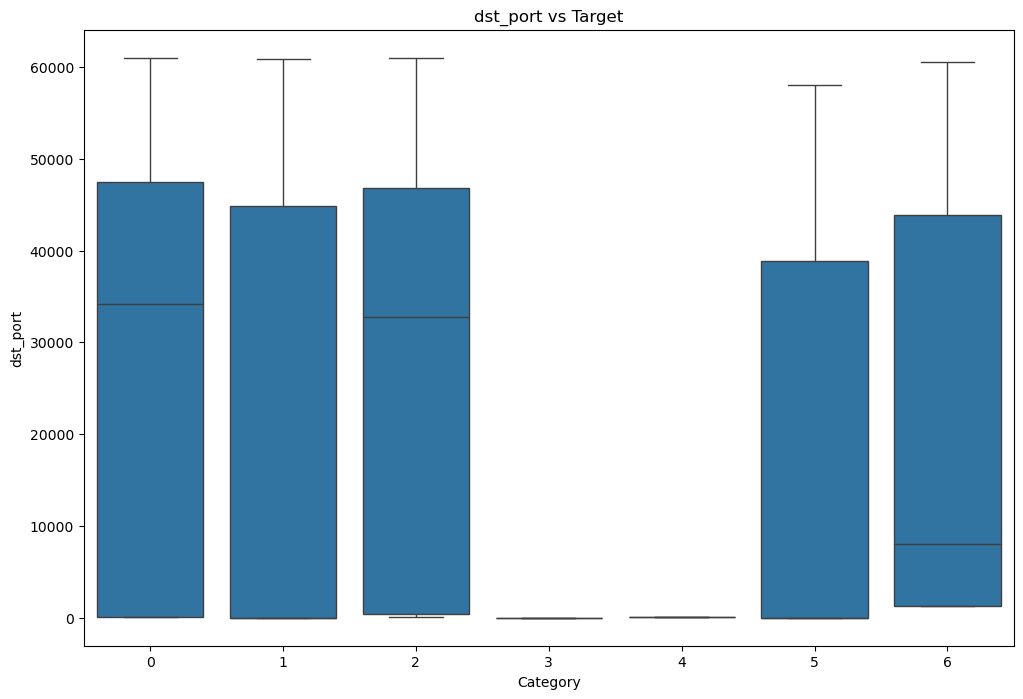

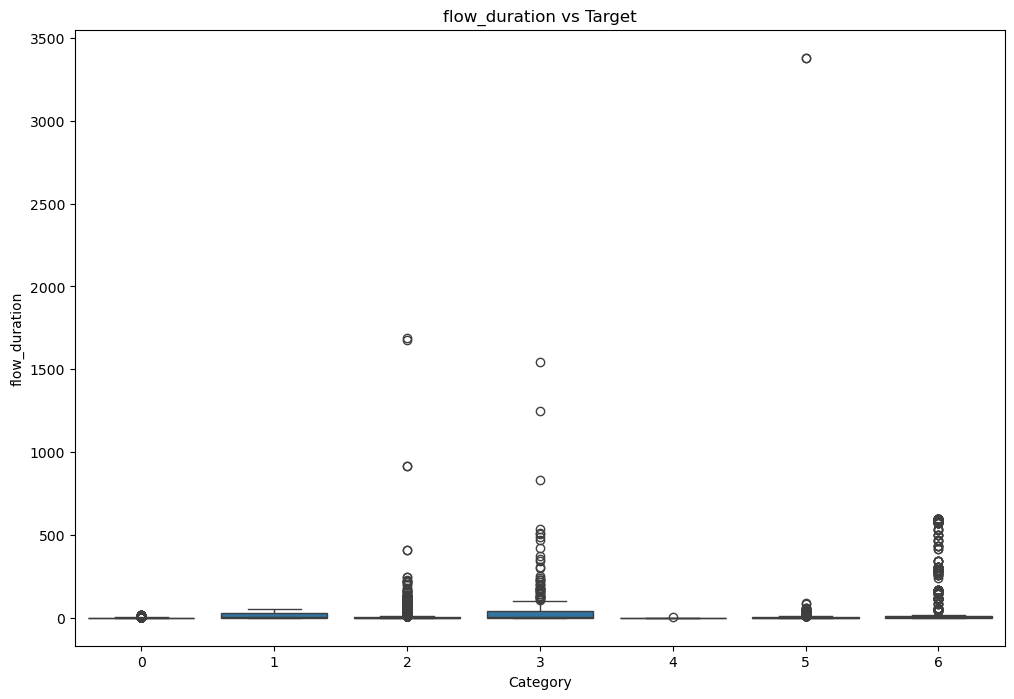

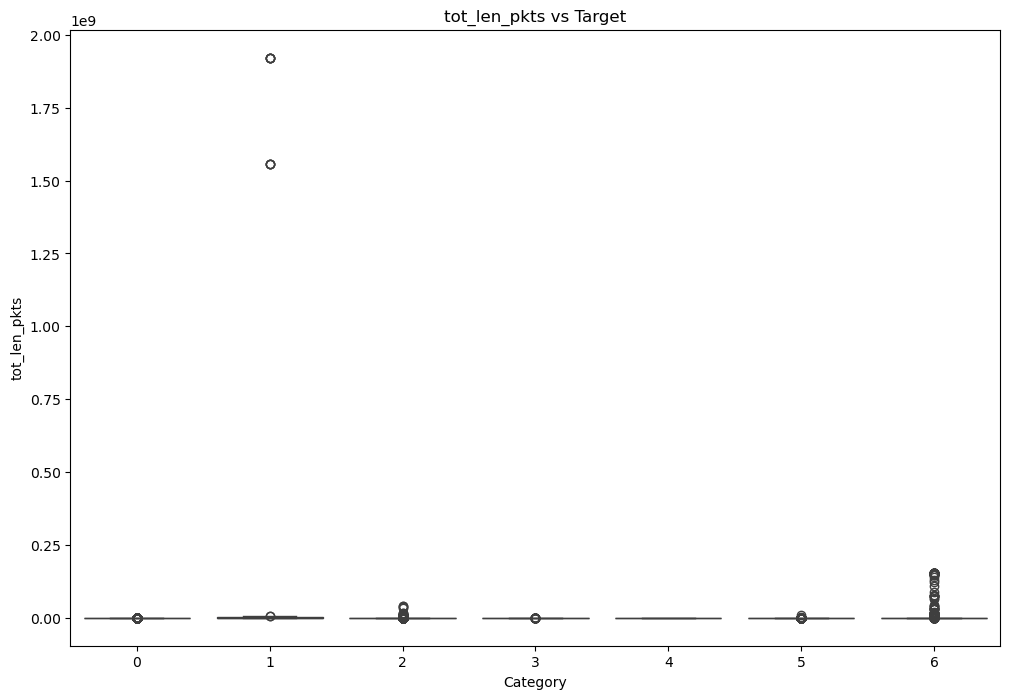

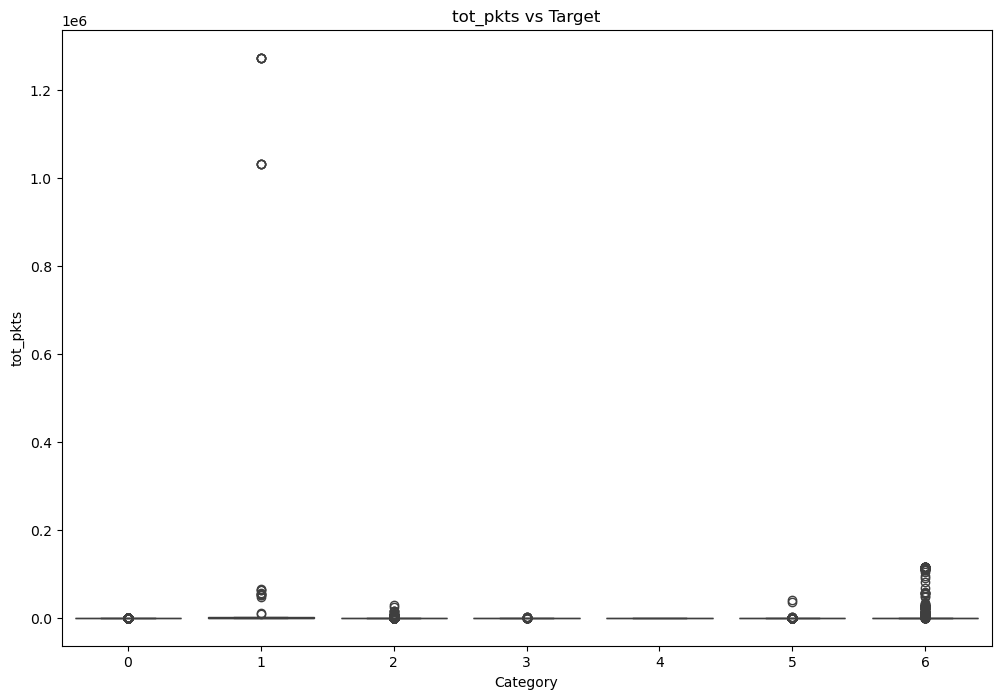

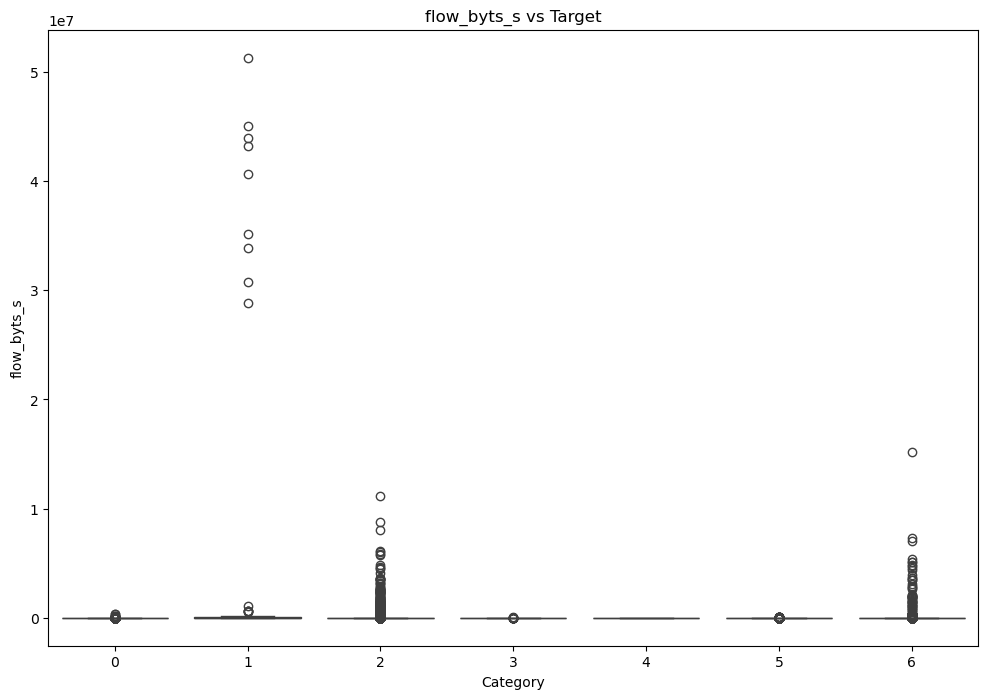

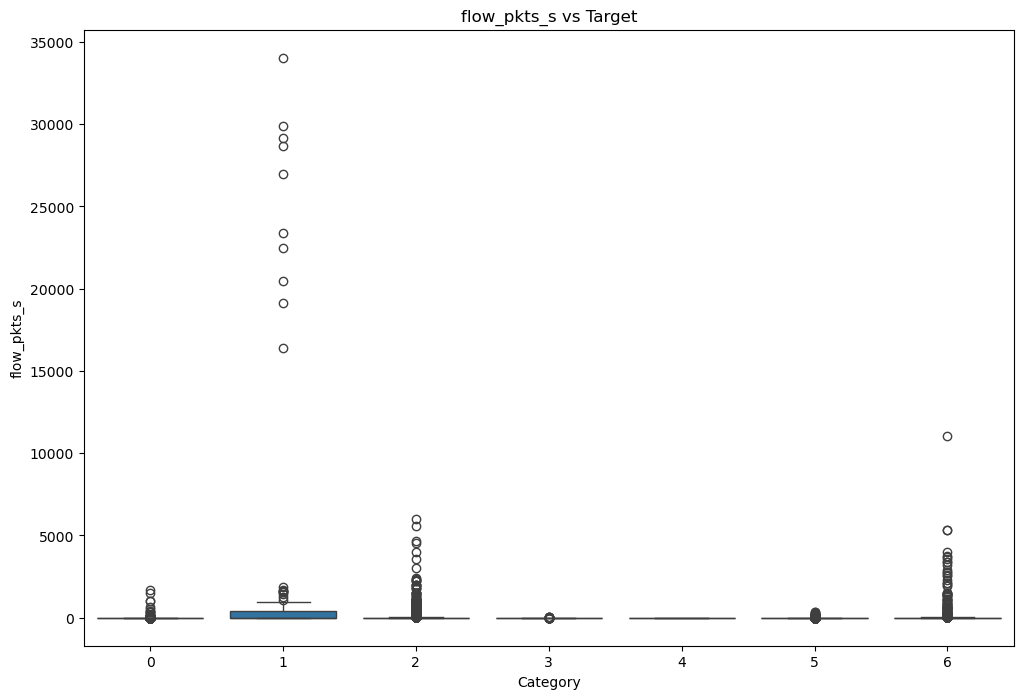

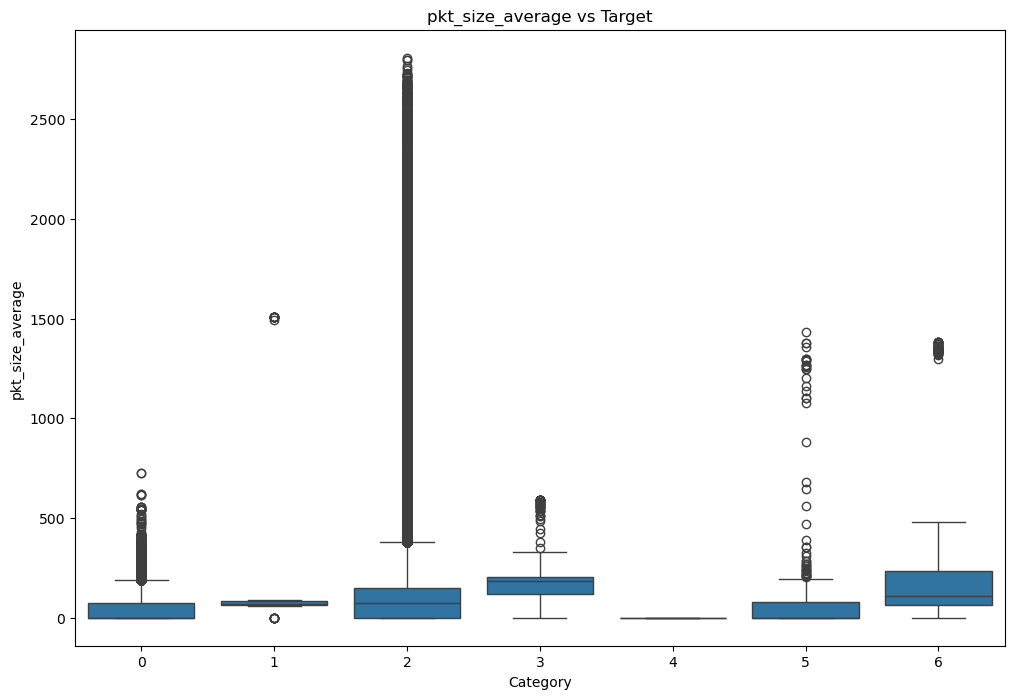

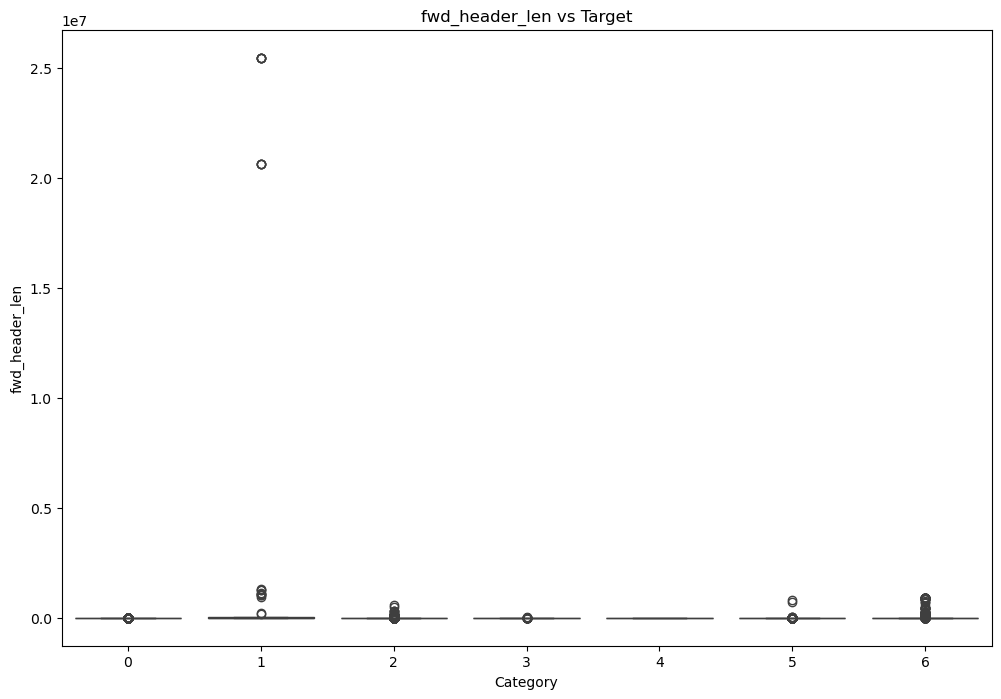

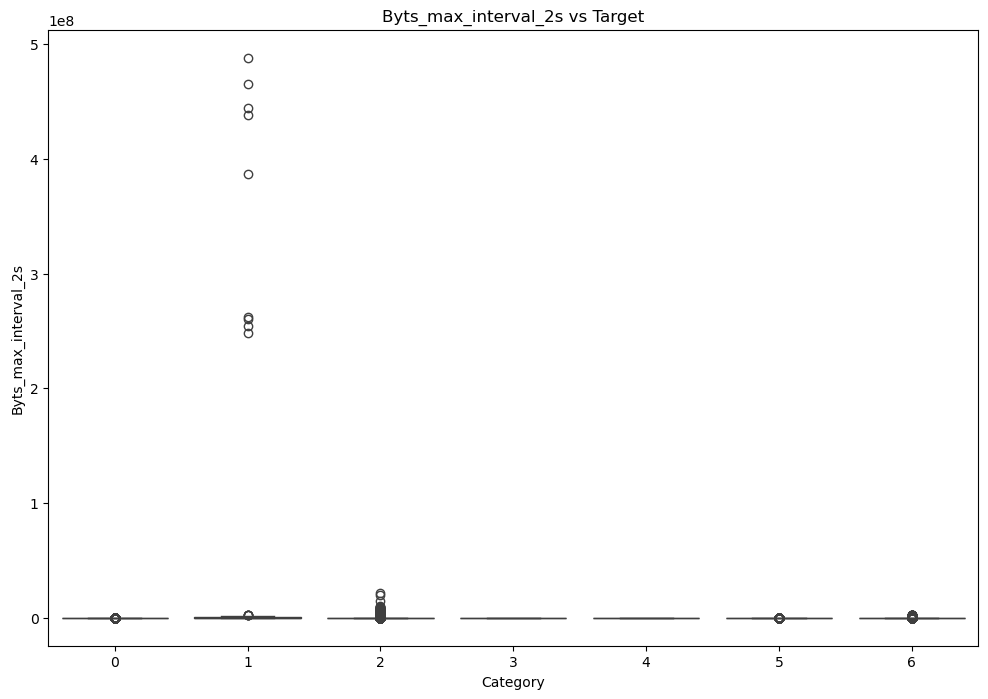

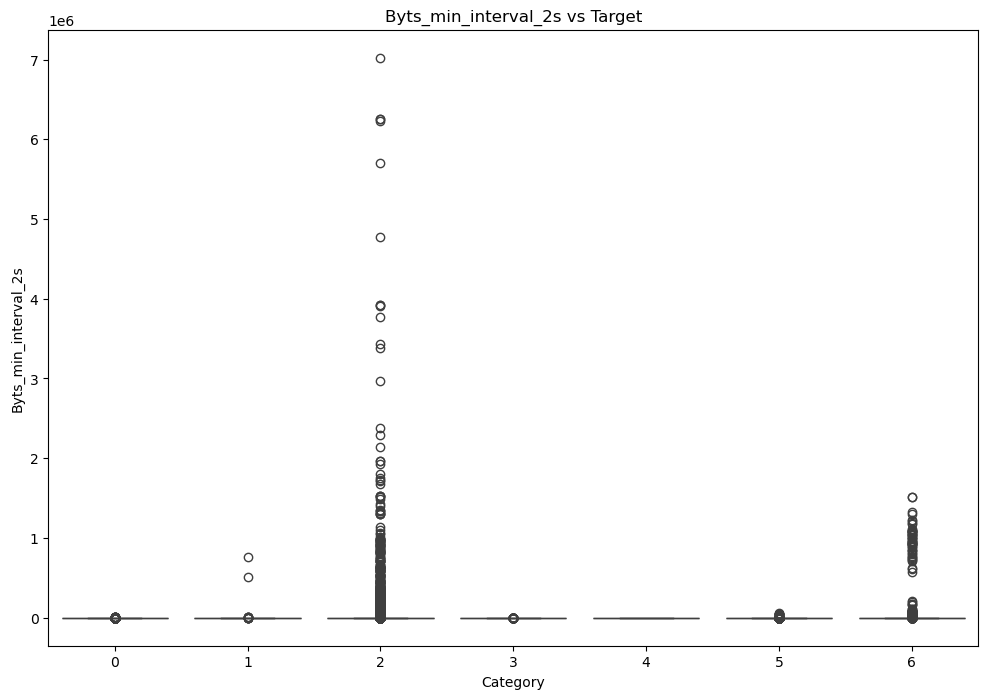

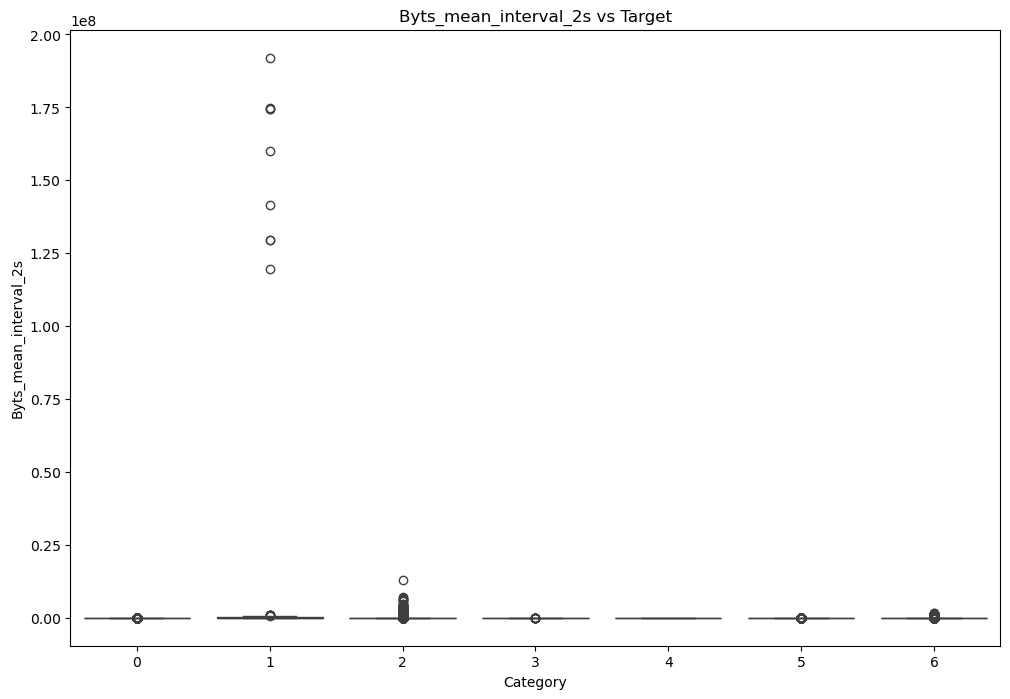

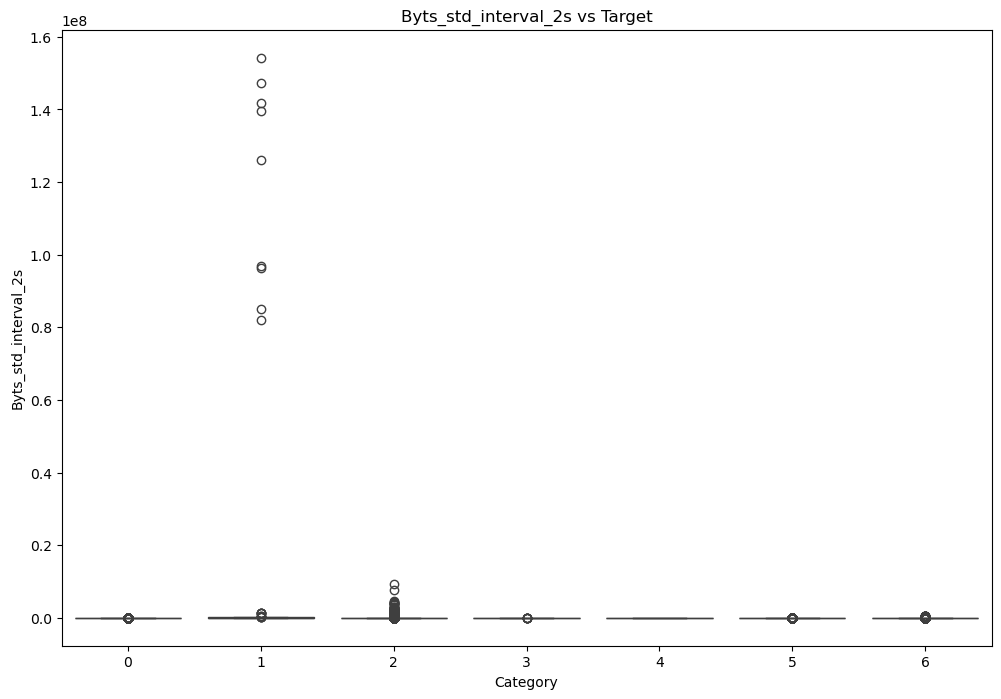

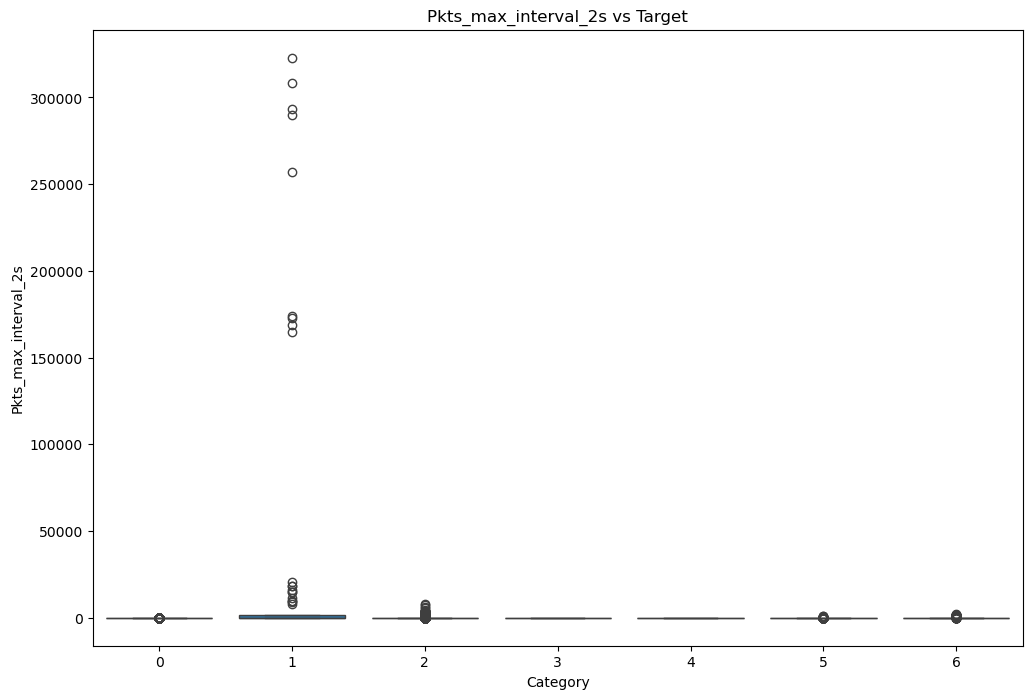

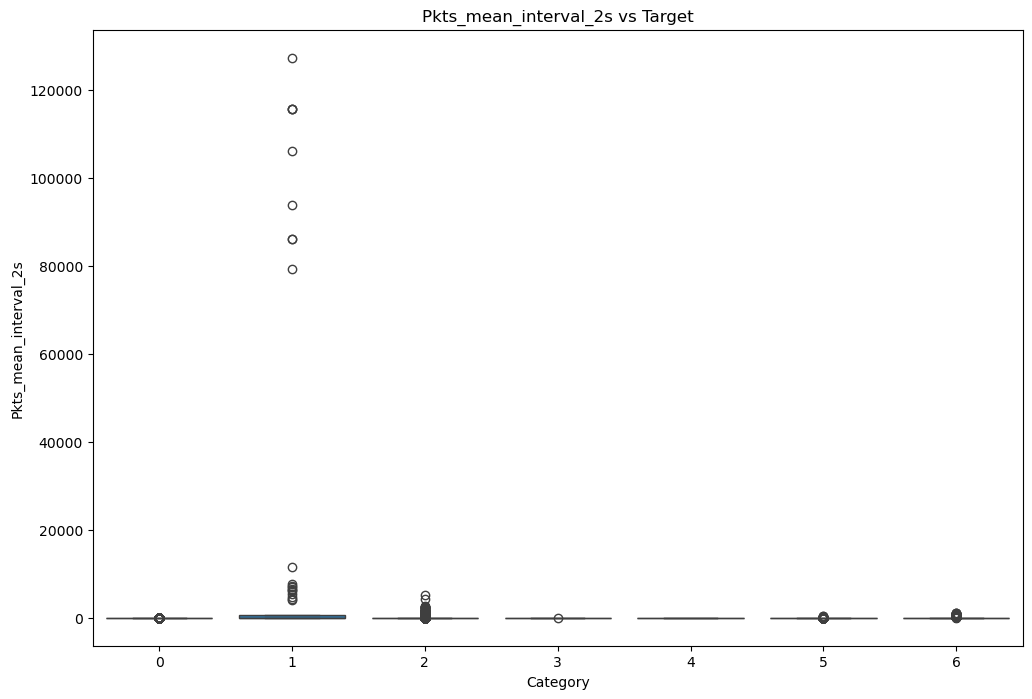

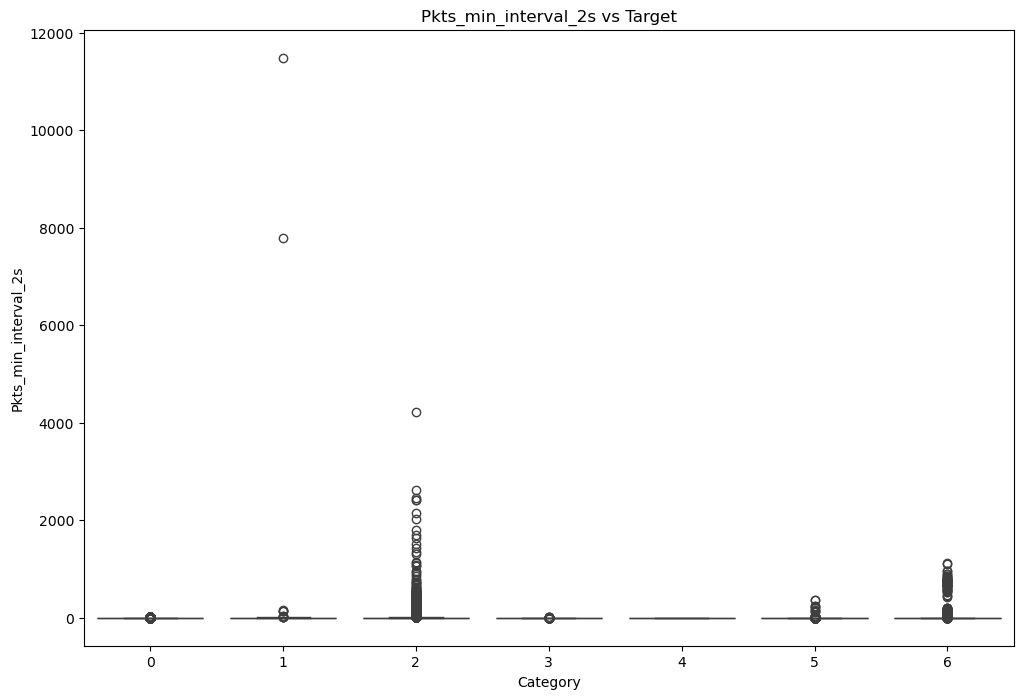

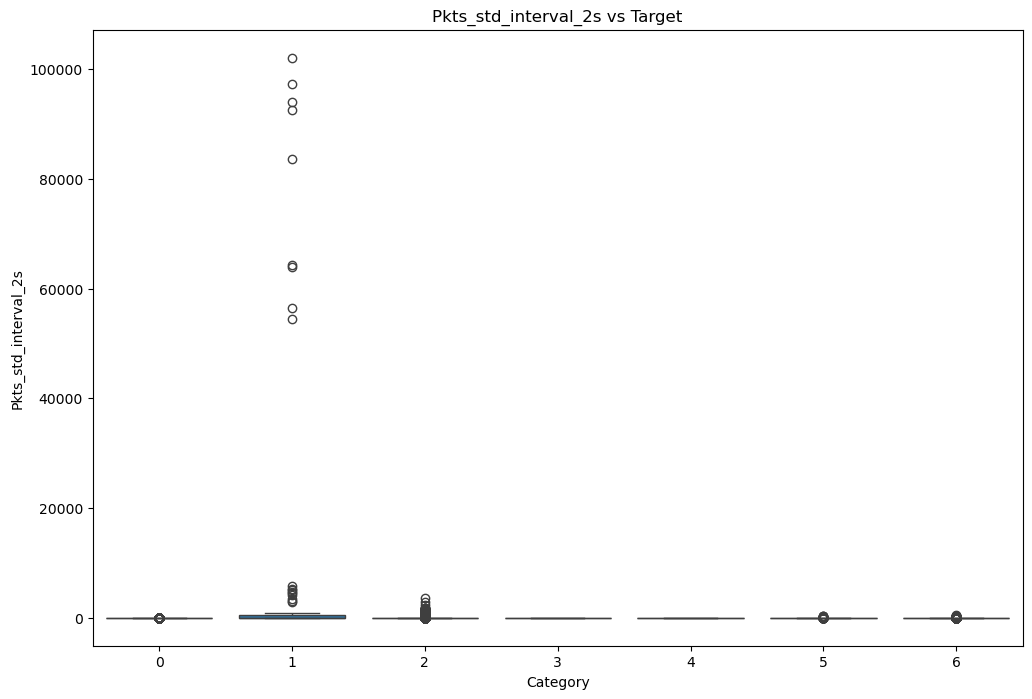

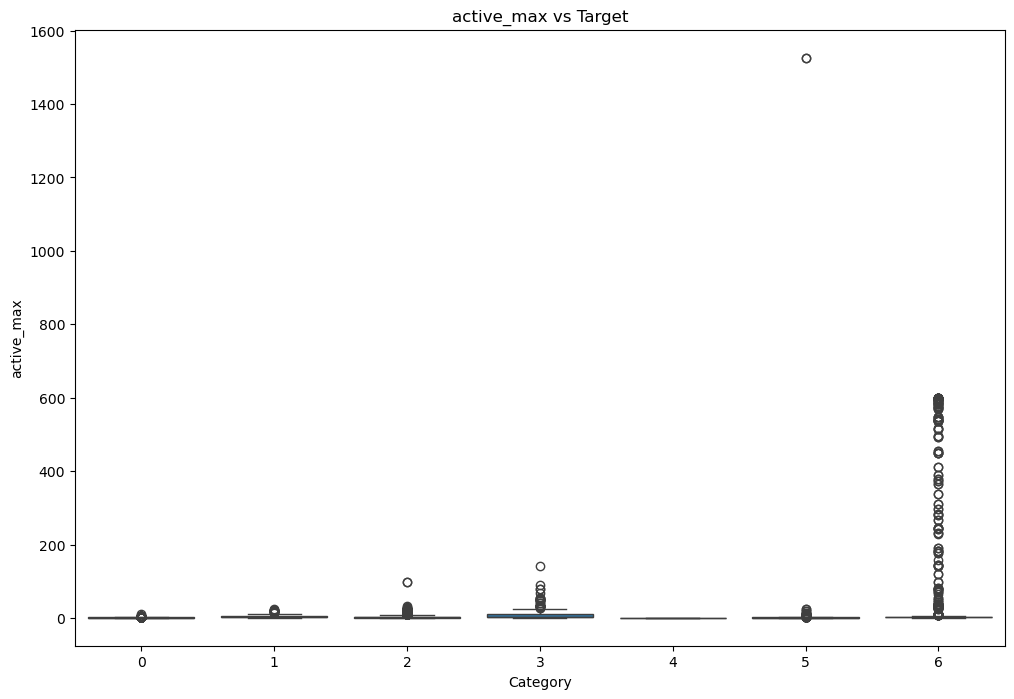

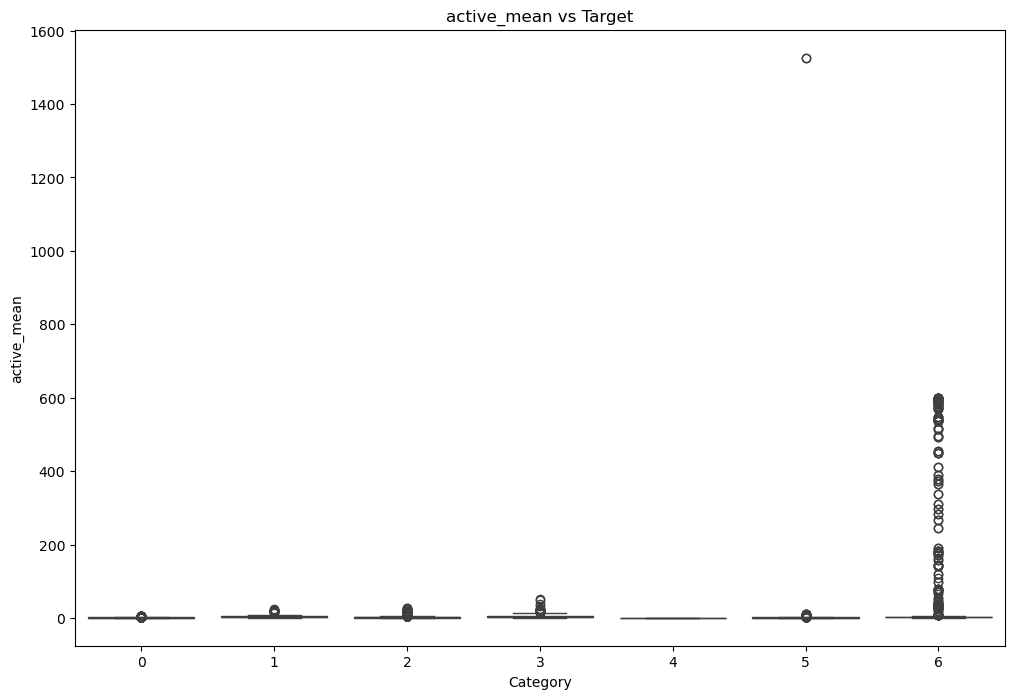

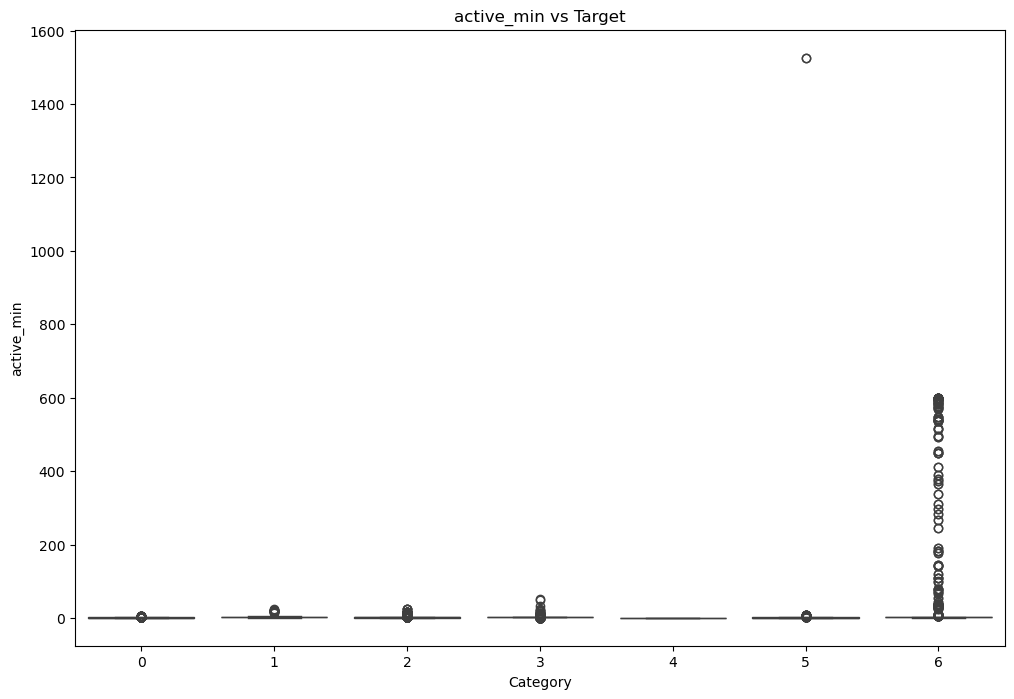

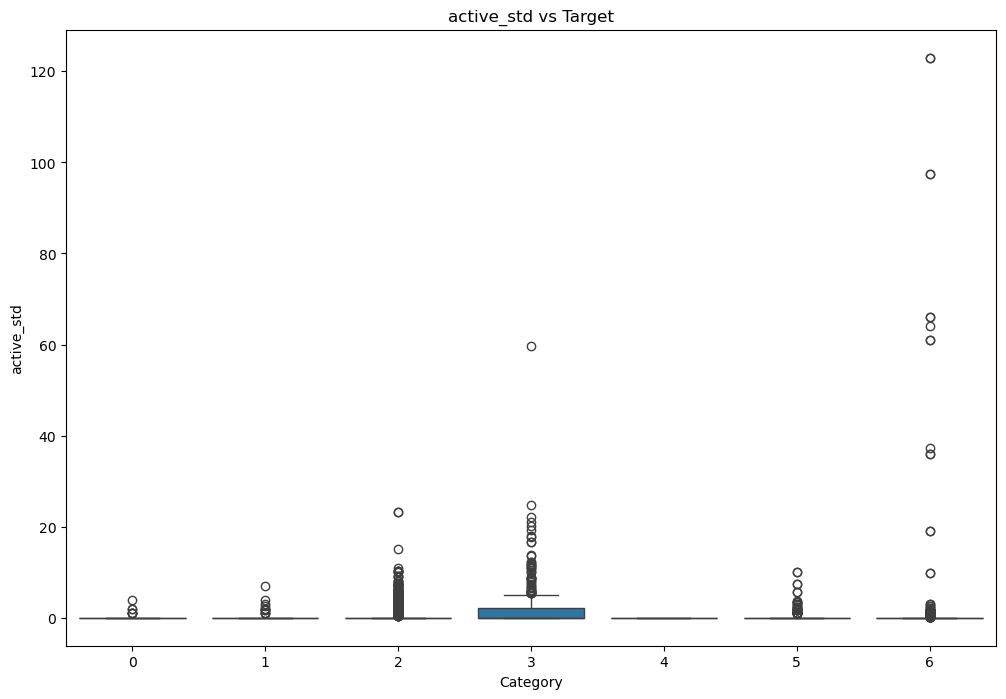

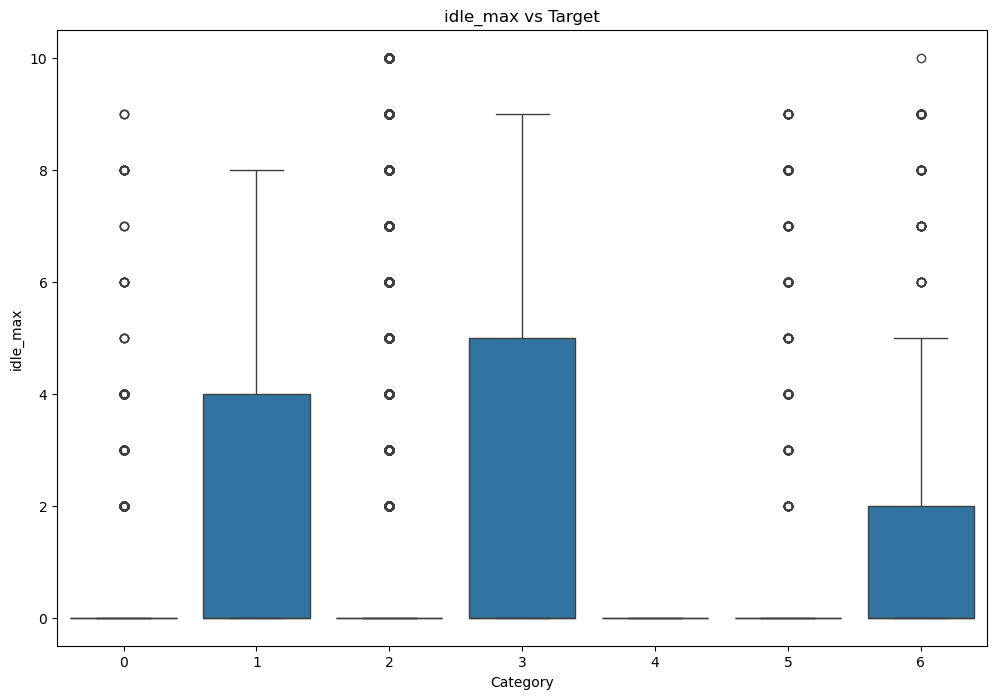

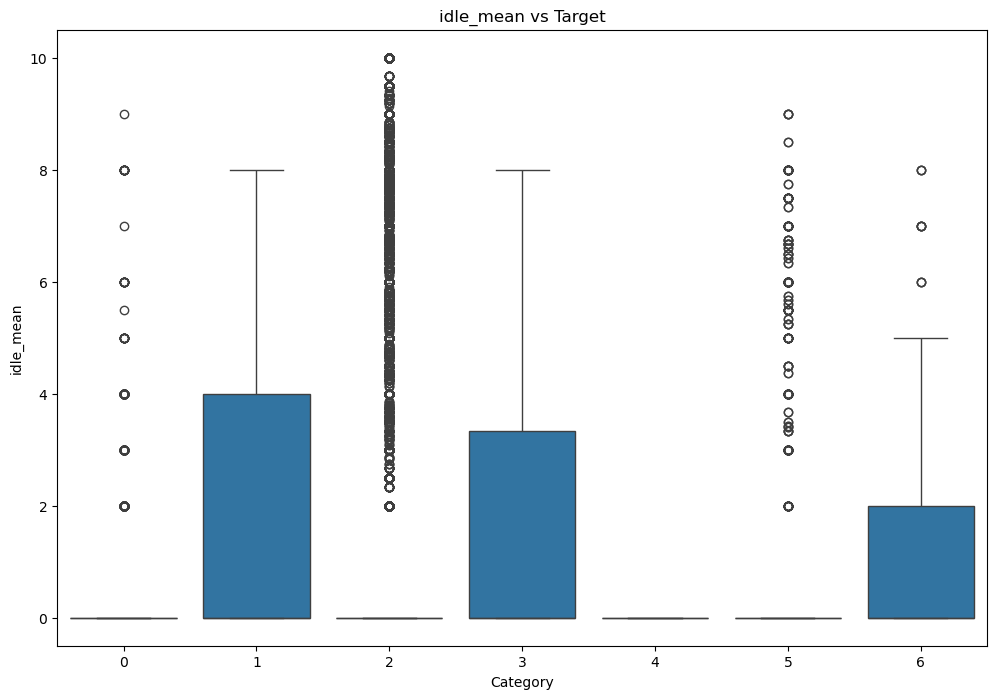

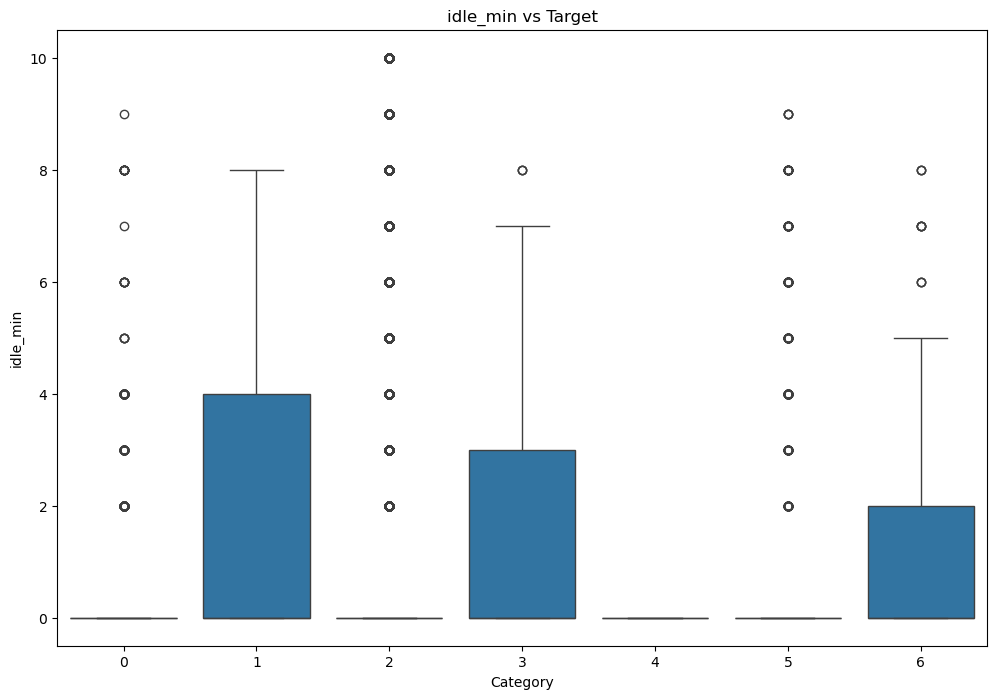

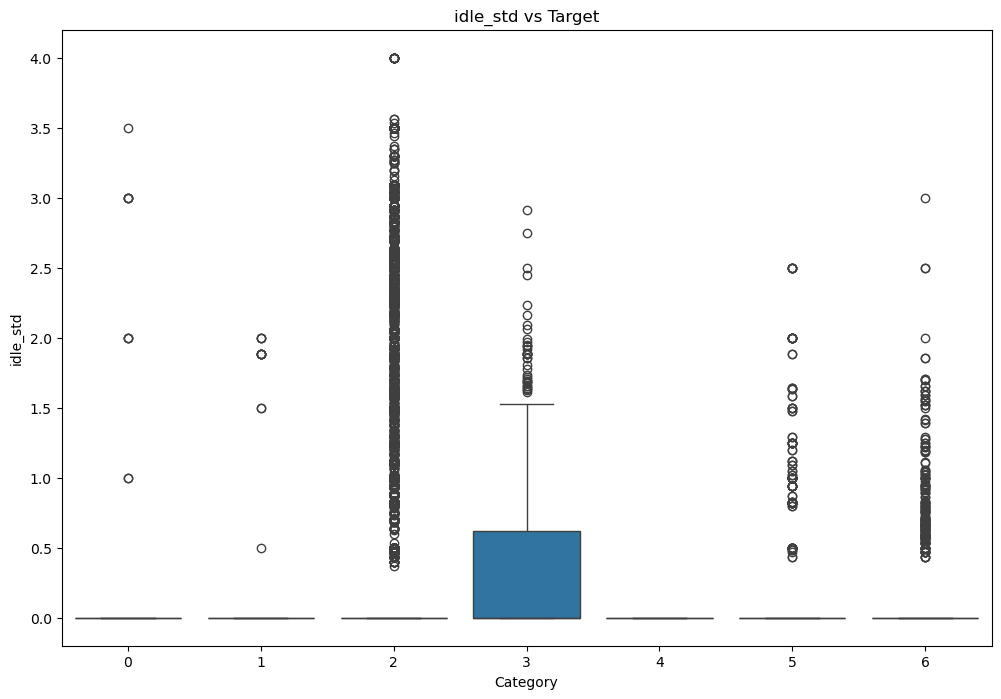

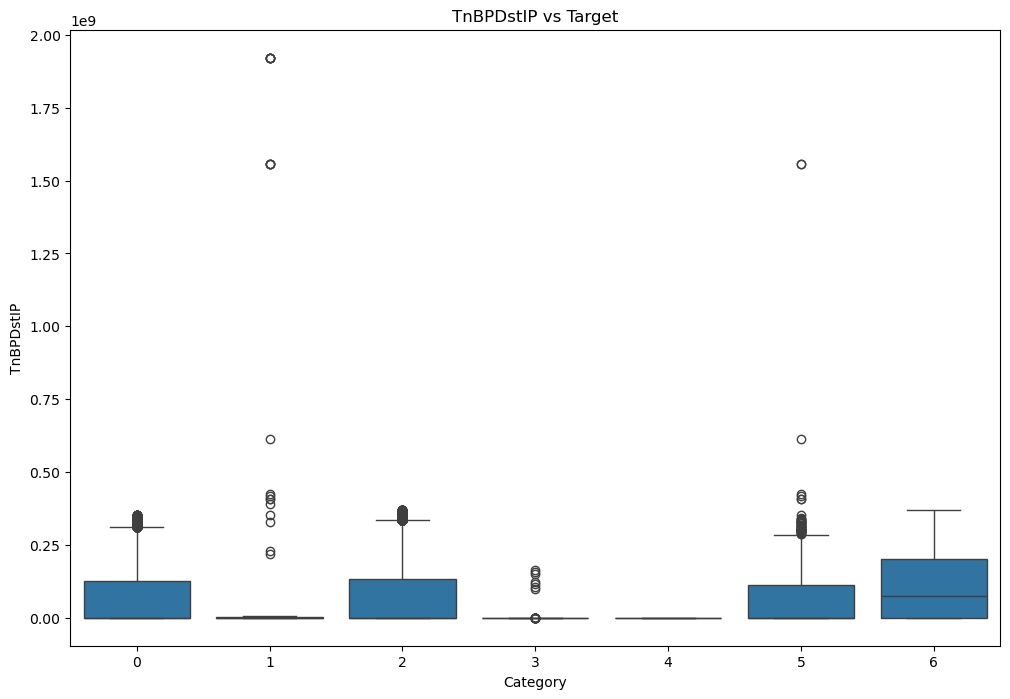

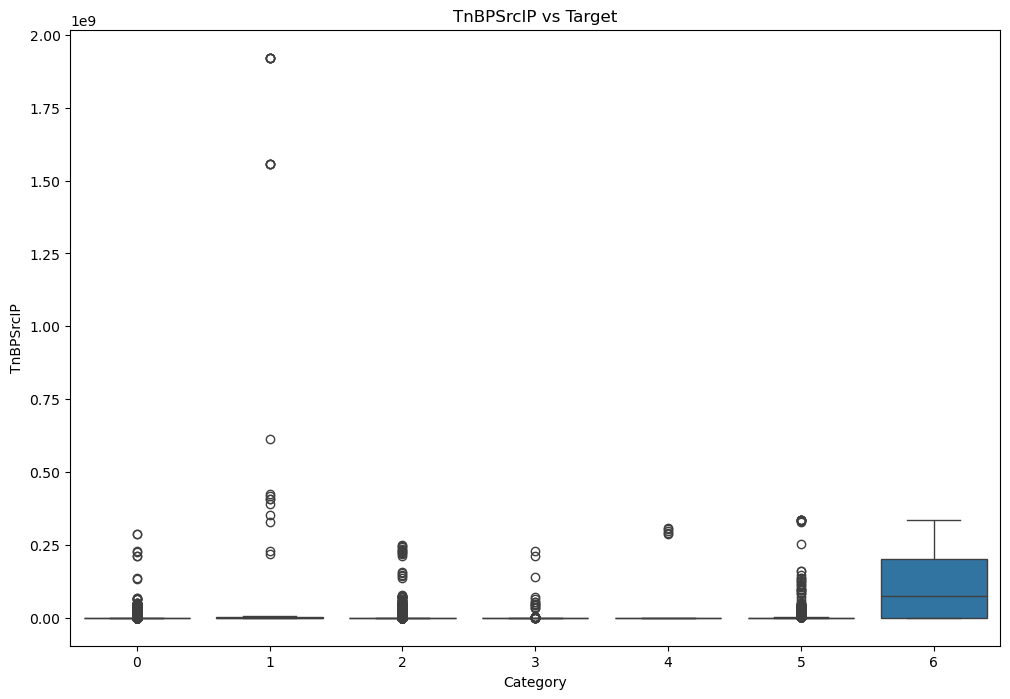

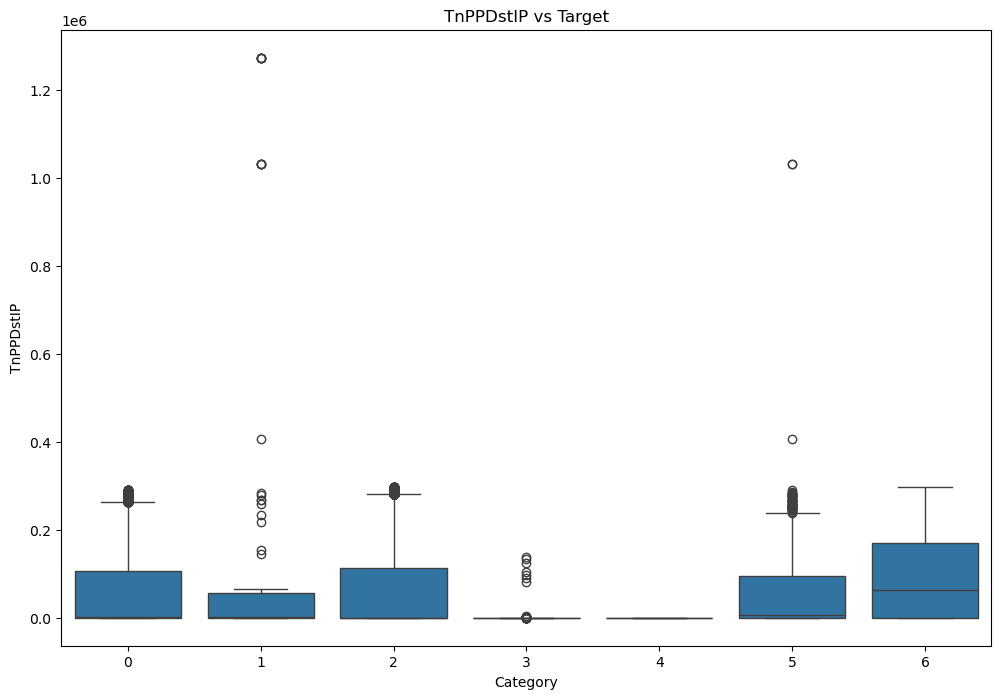

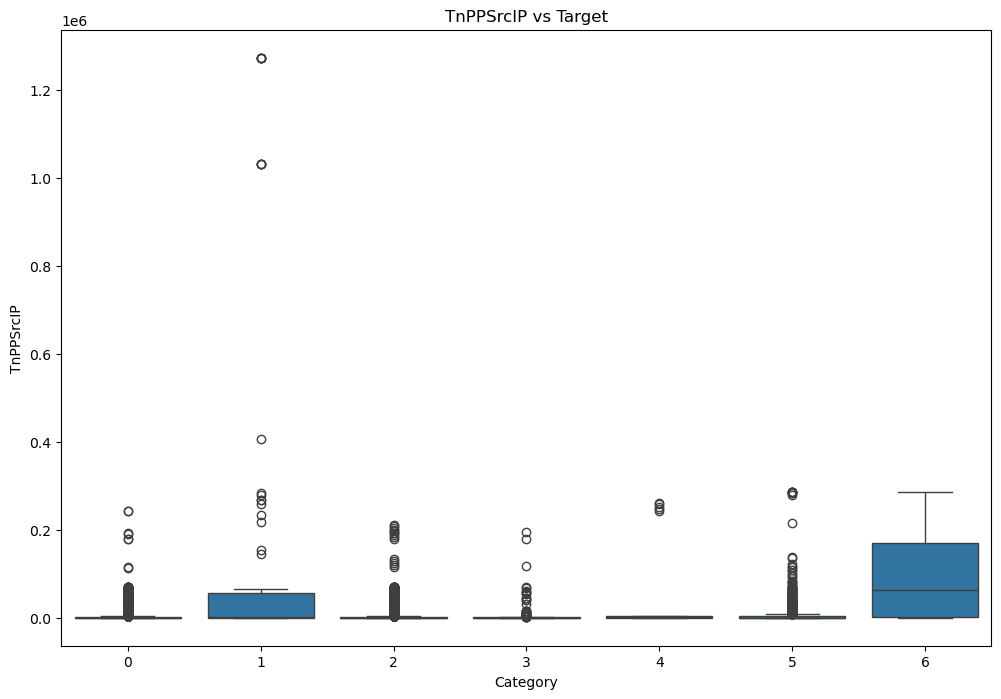

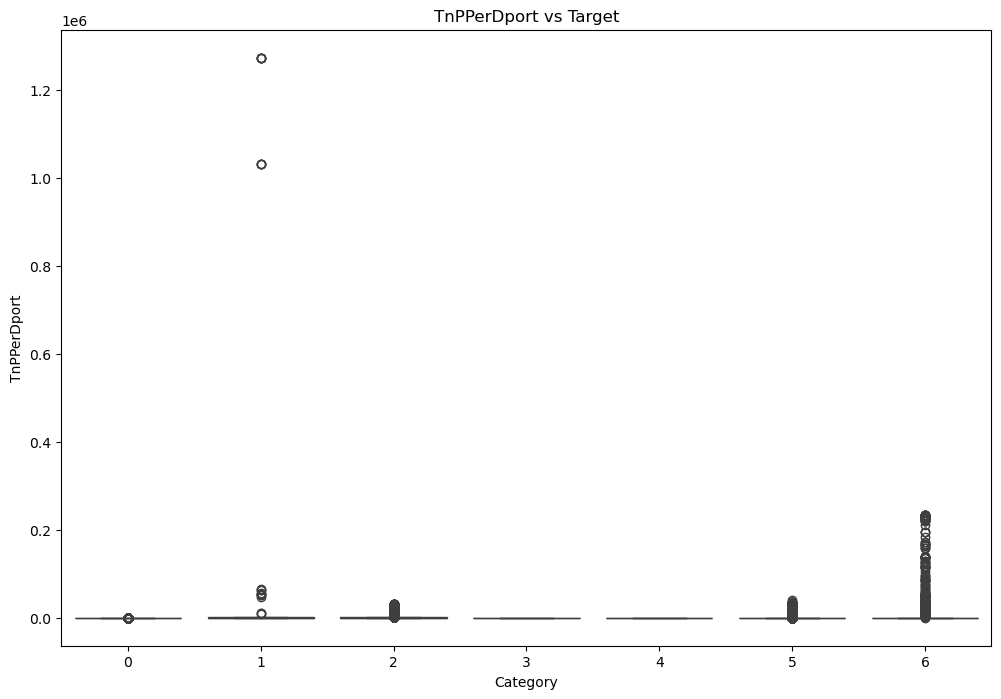

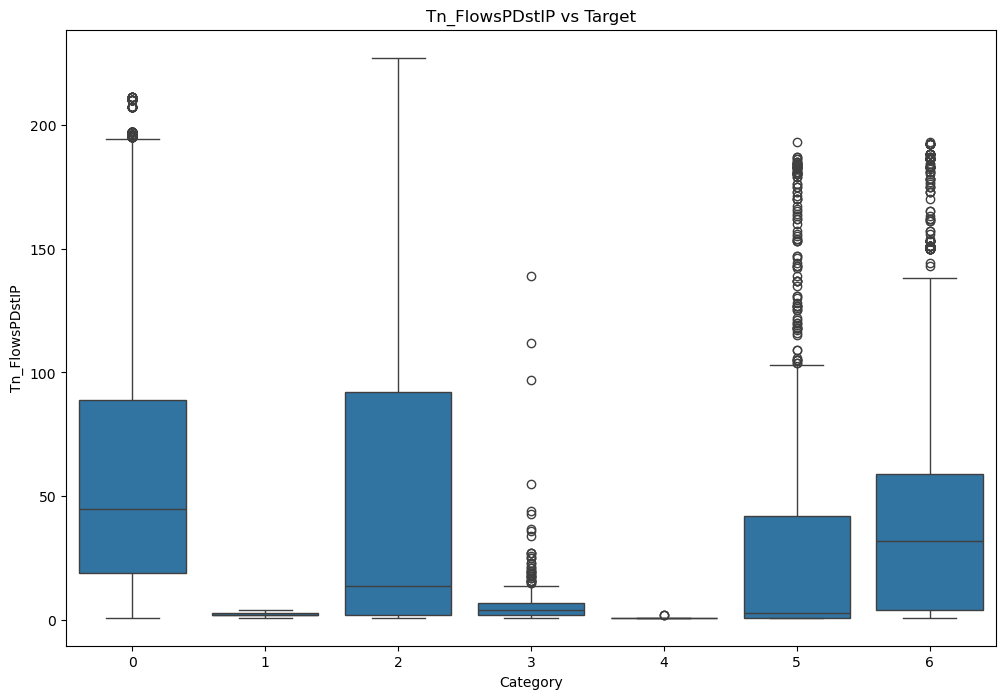

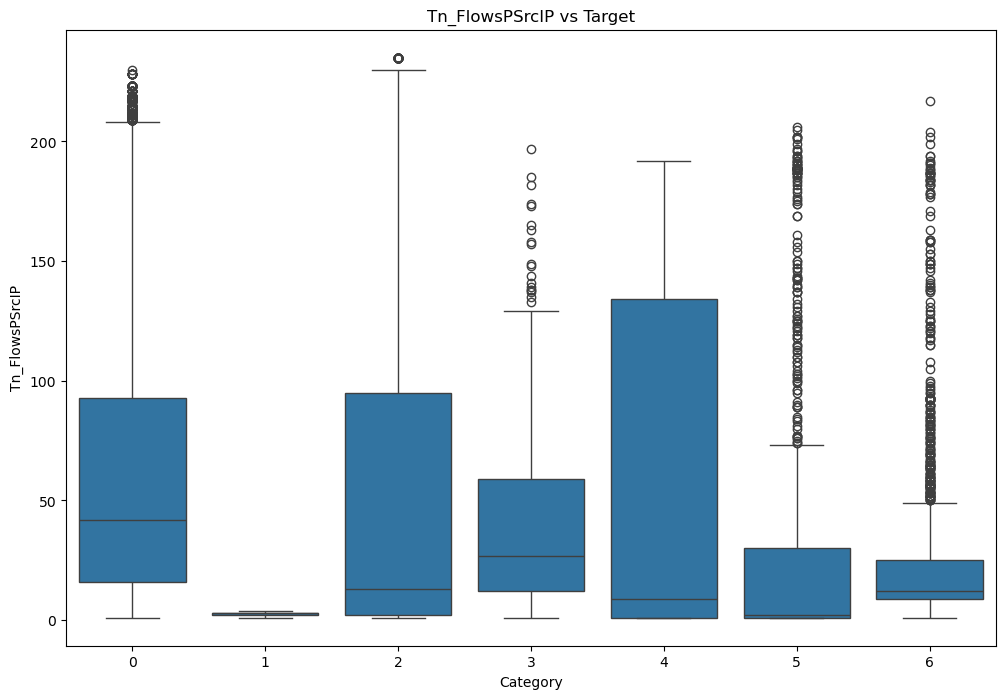

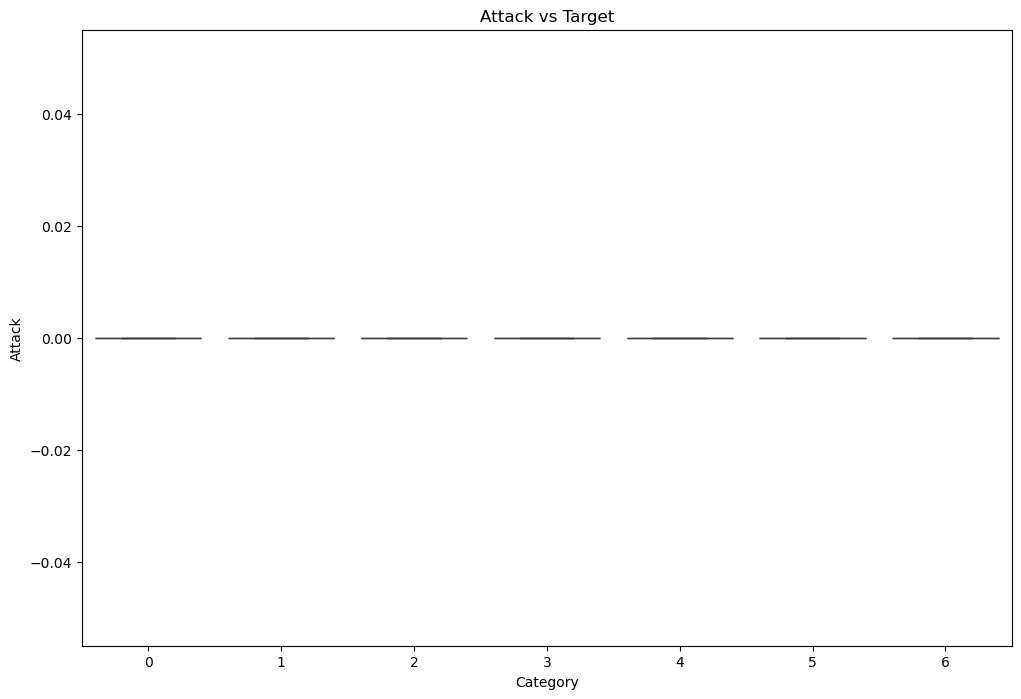

In [331]:
for col in num_cols:
    plt.figure(figsize=(12,8))
    sns.boxplot(x=df2[target], y=df2[col])
    plt.title(f"{col} vs Target")
    plt.show()


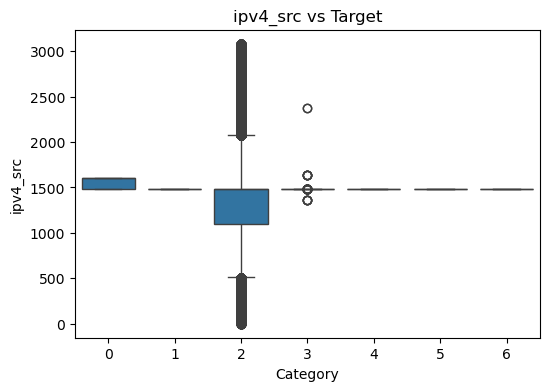

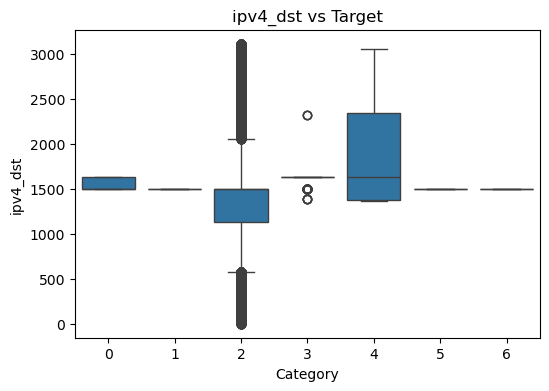

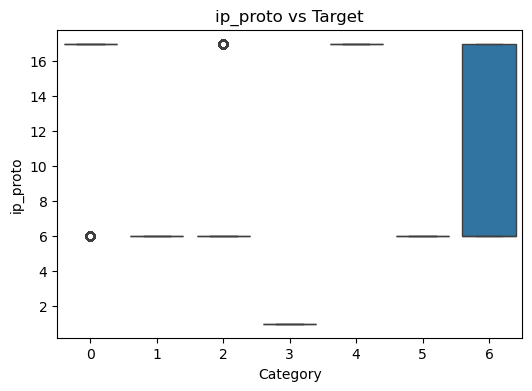

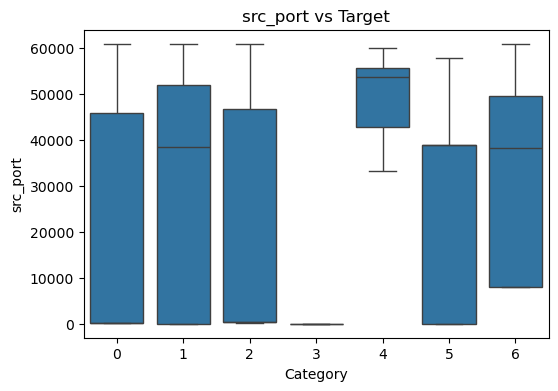

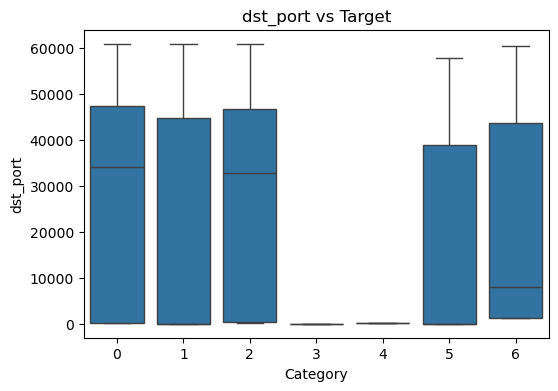

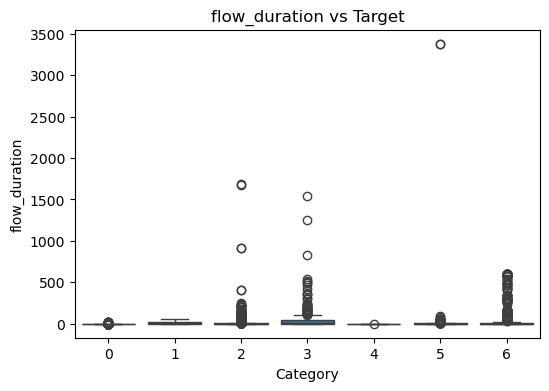

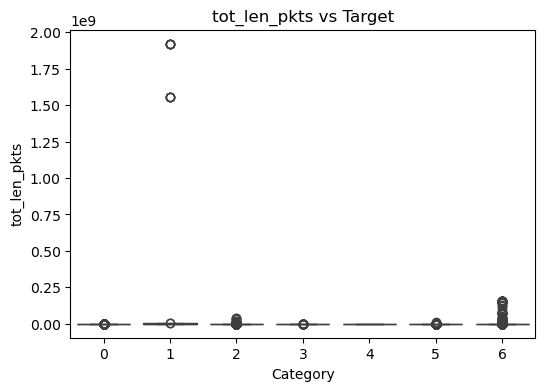

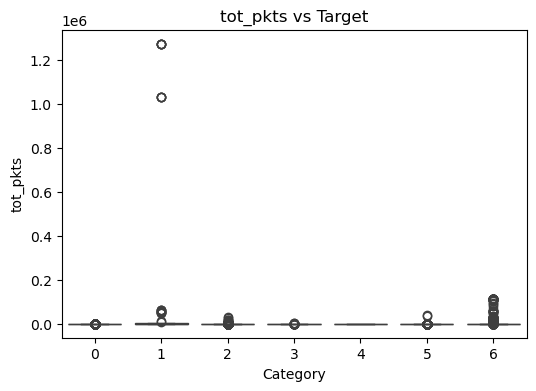

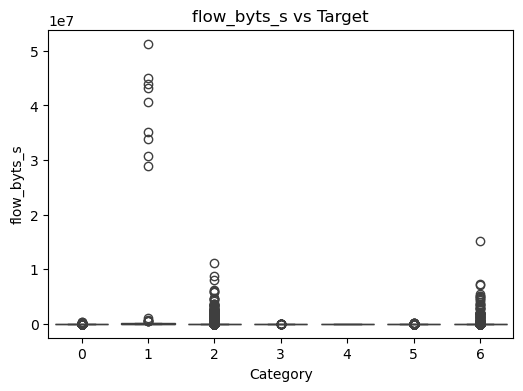

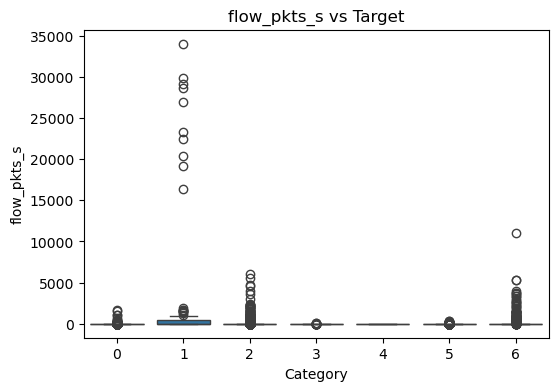

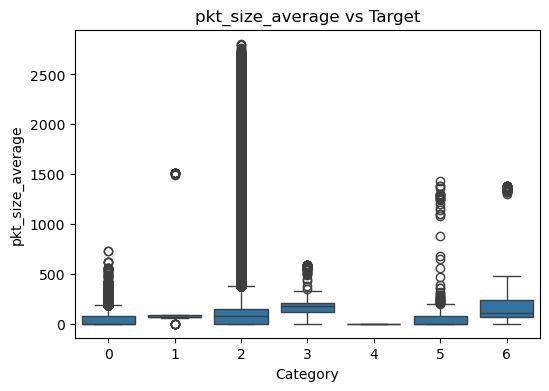

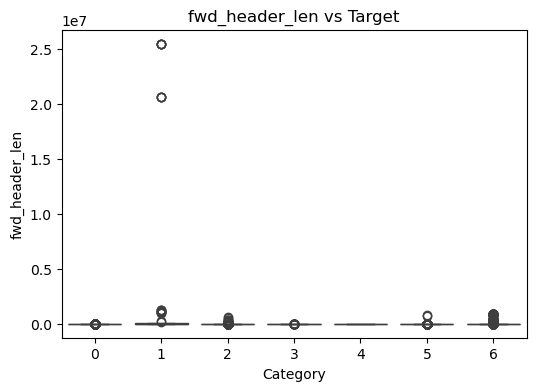

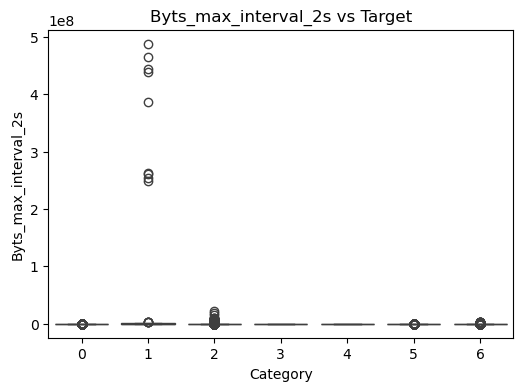

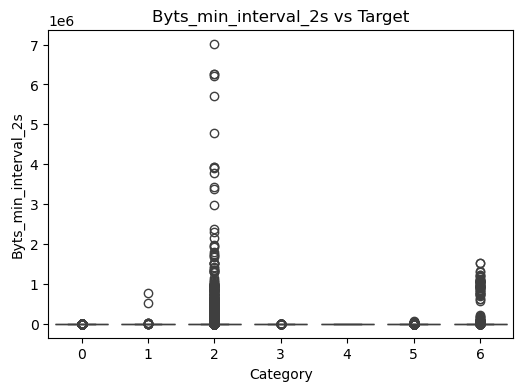

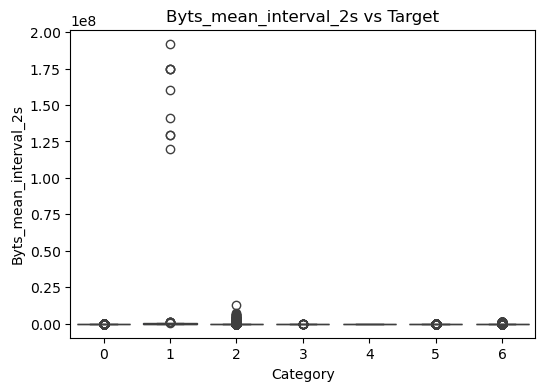

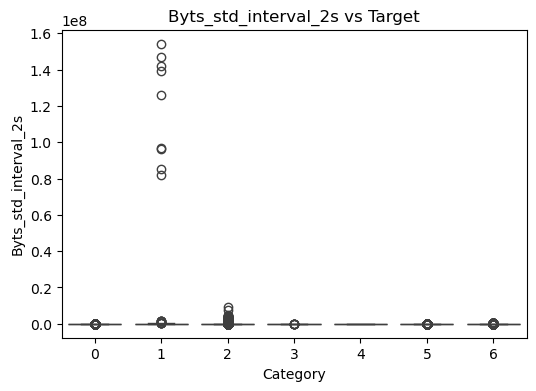

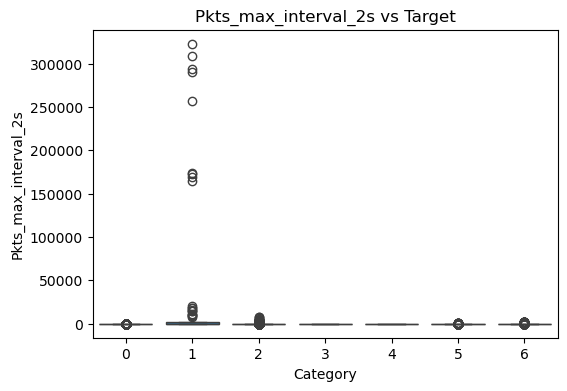

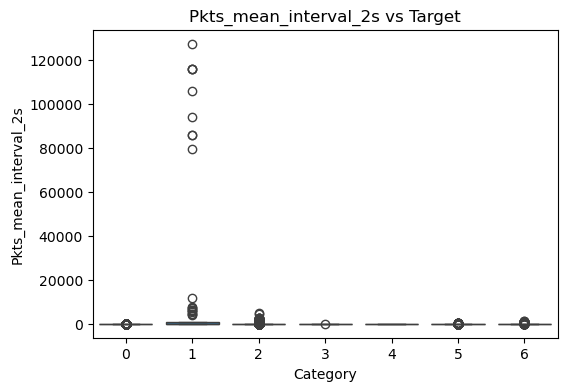

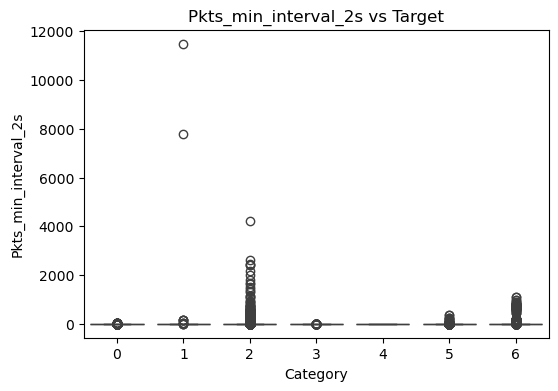

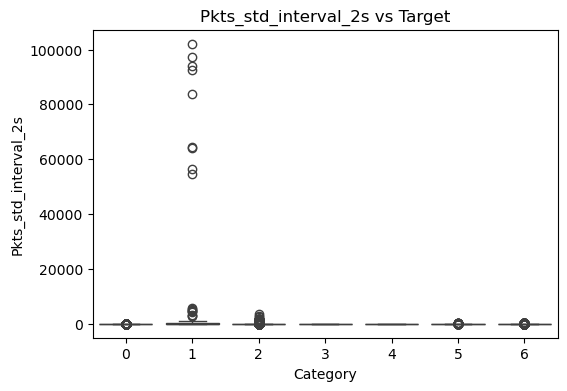

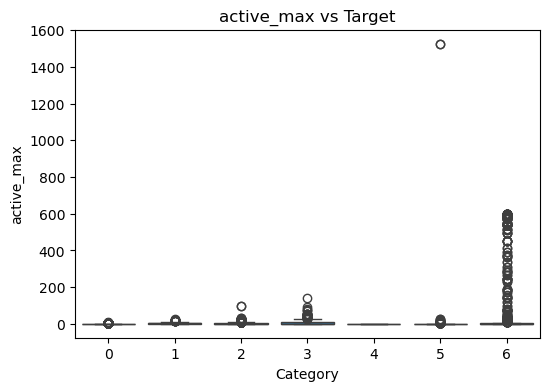

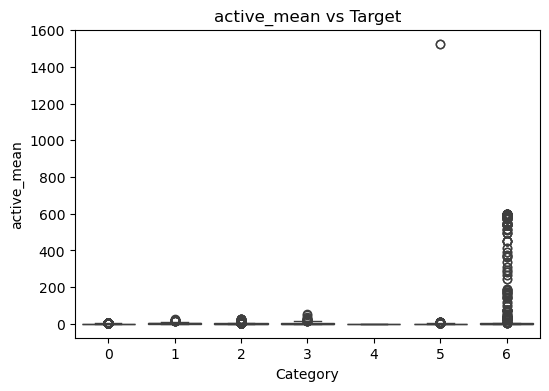

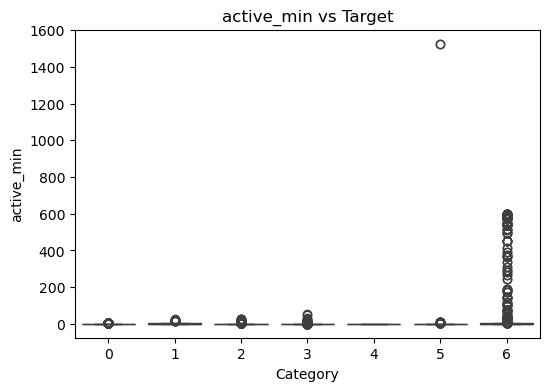

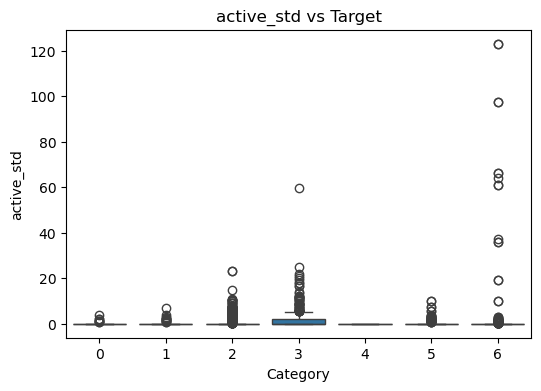

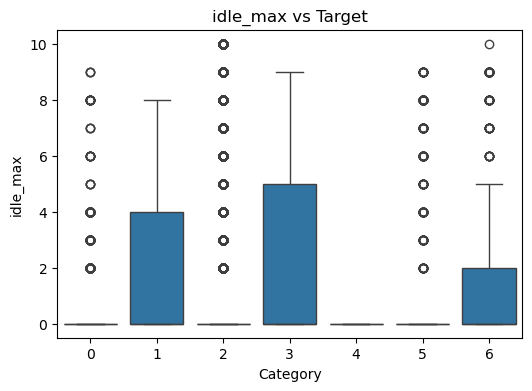

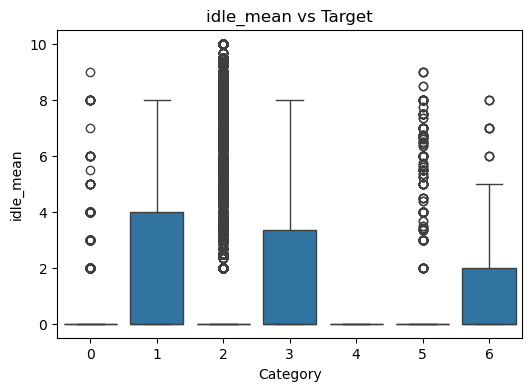

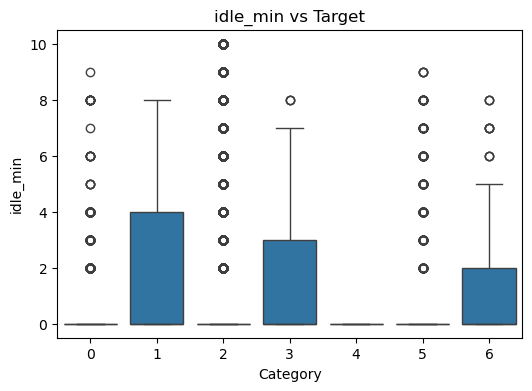

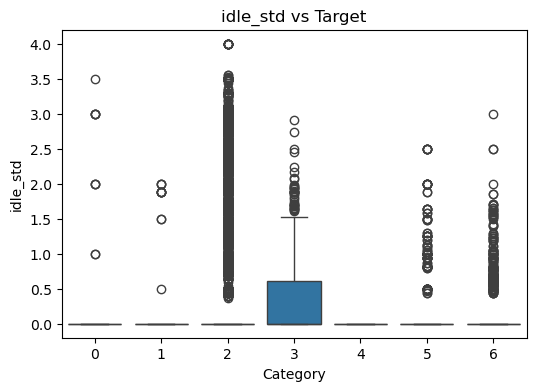

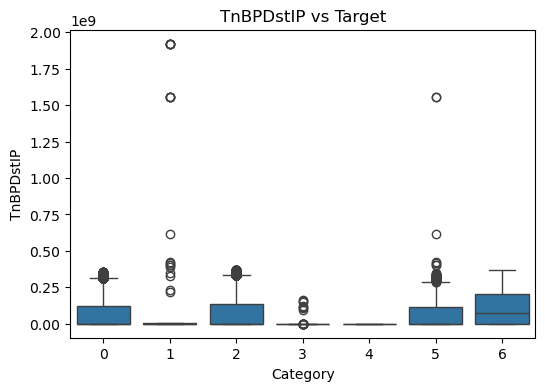

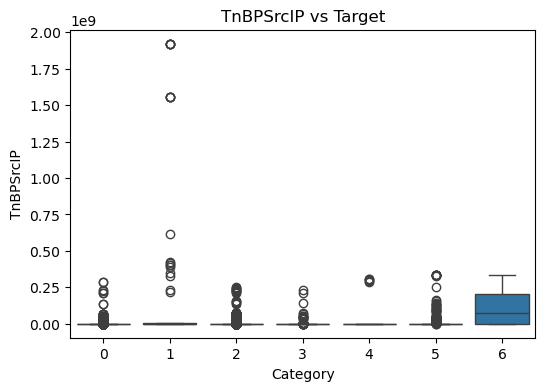

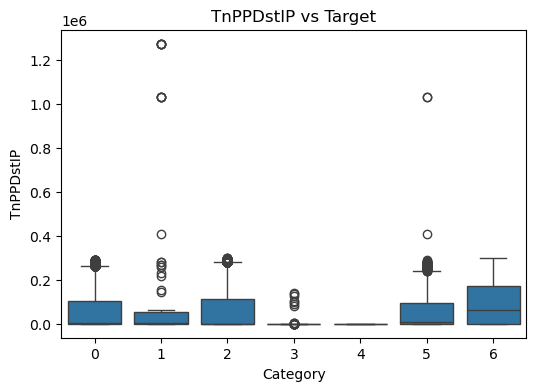

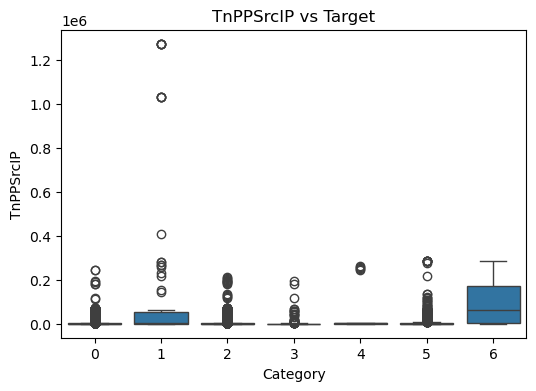

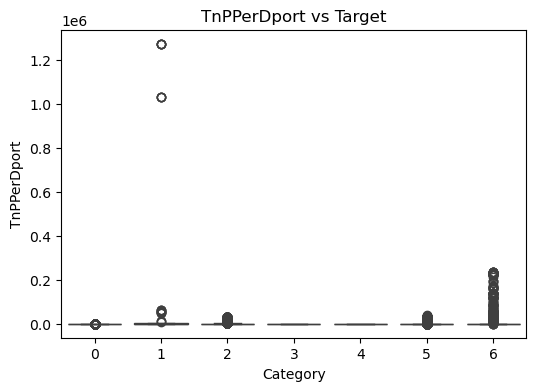

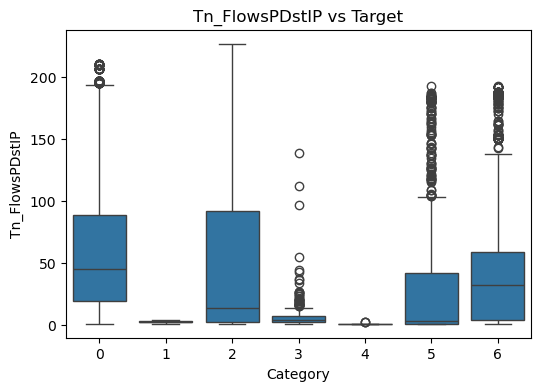

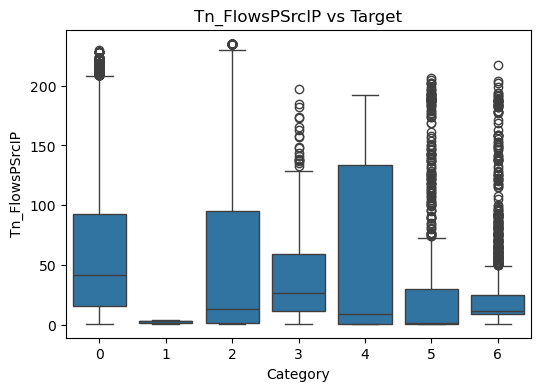

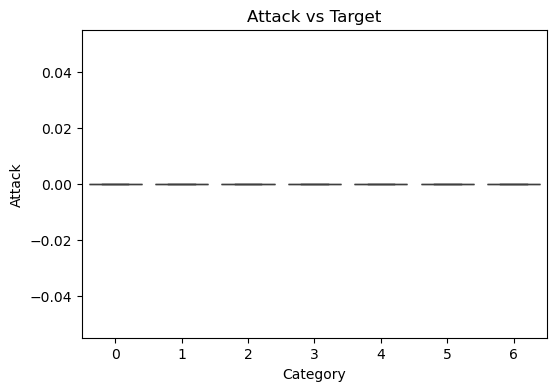

In [332]:
for col in num_cols:
    plt.figure(figsize=(6,4))
    ## for outliers
    sns.boxplot(x=df2[target], y=df2[col])
    plt.title(f"{col} vs Target")
    plt.show()


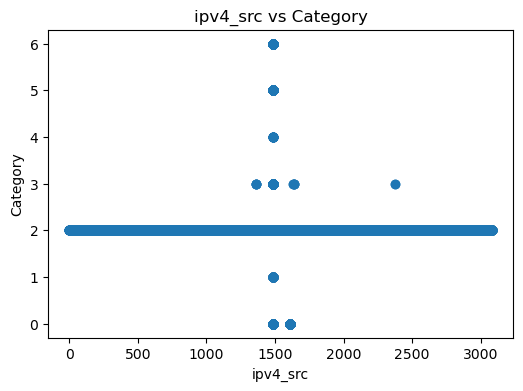

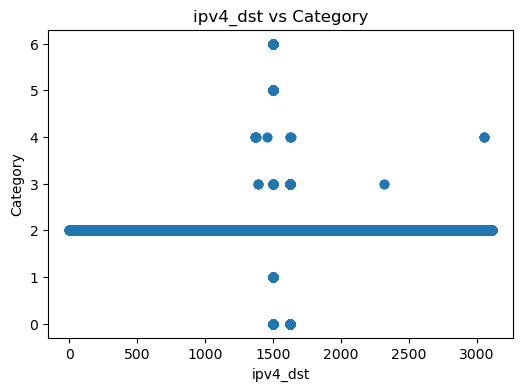

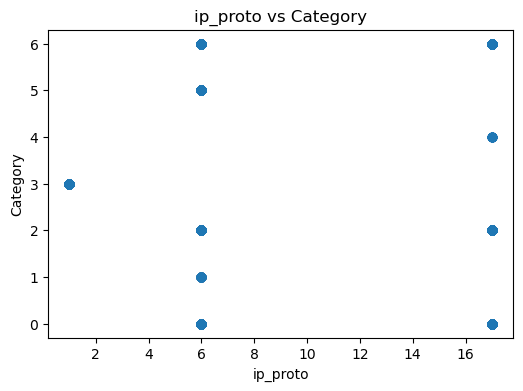

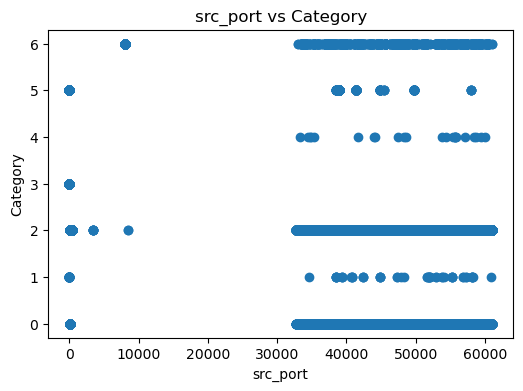

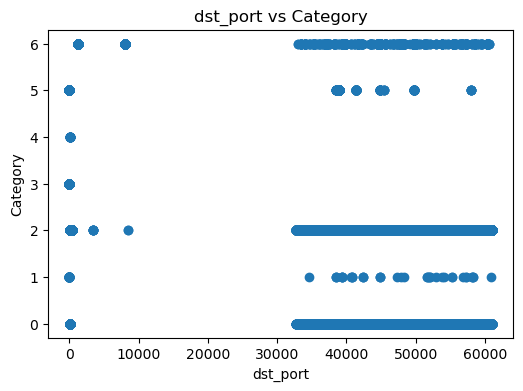

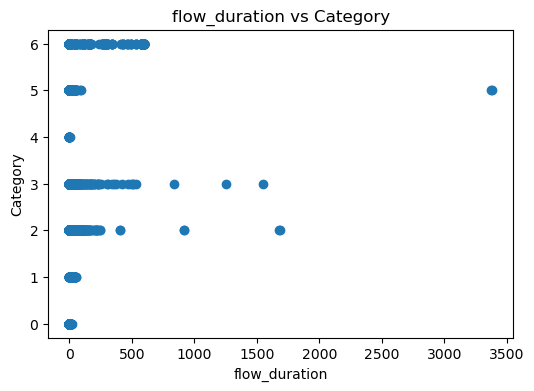

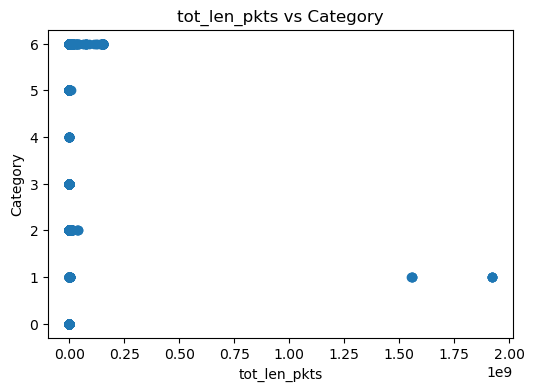

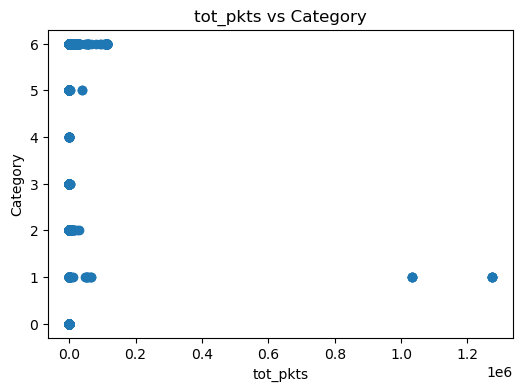

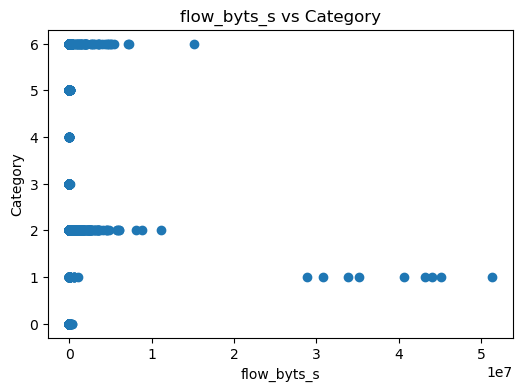

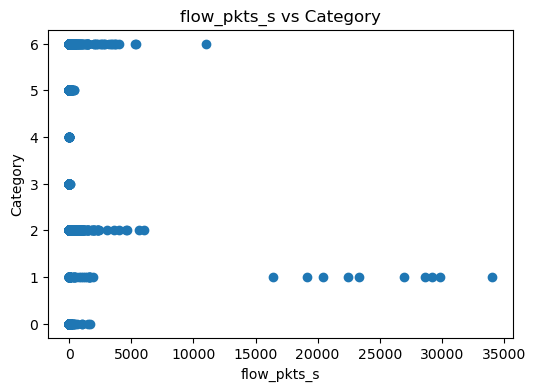

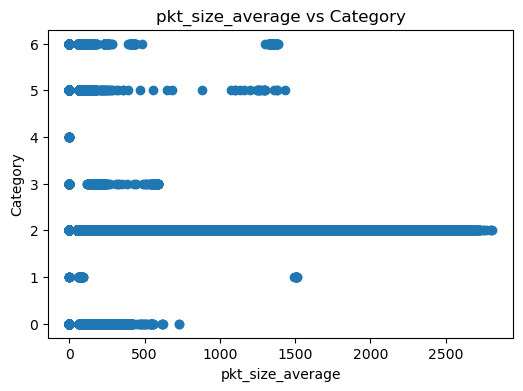

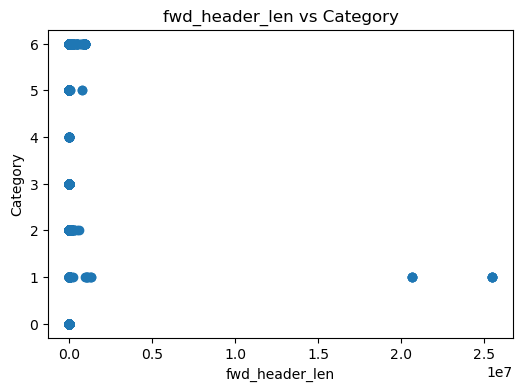

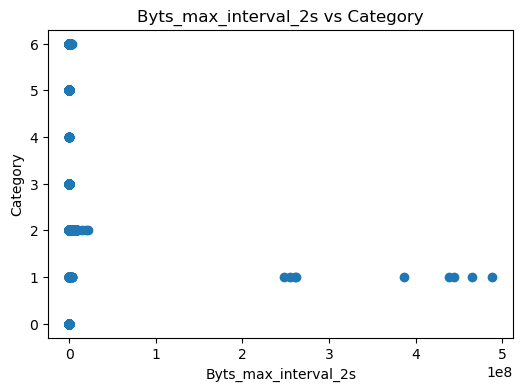

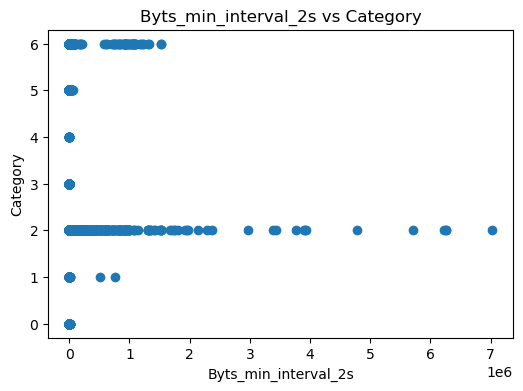

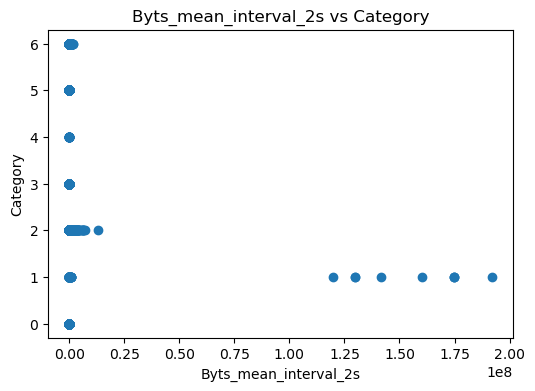

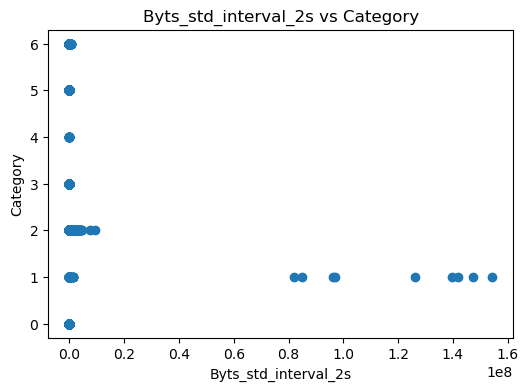

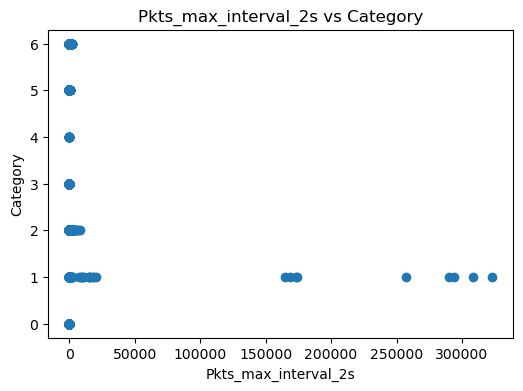

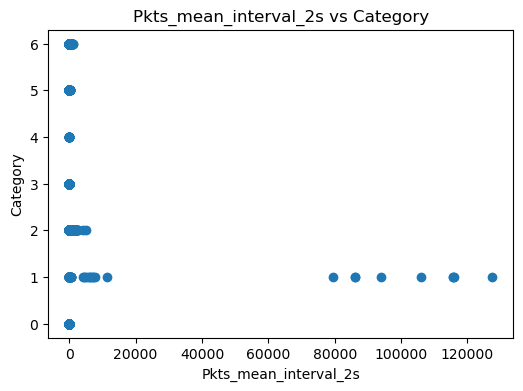

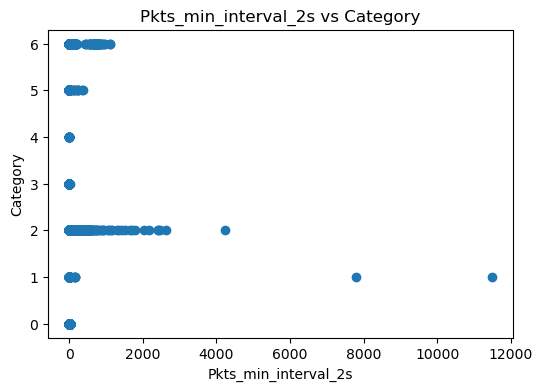

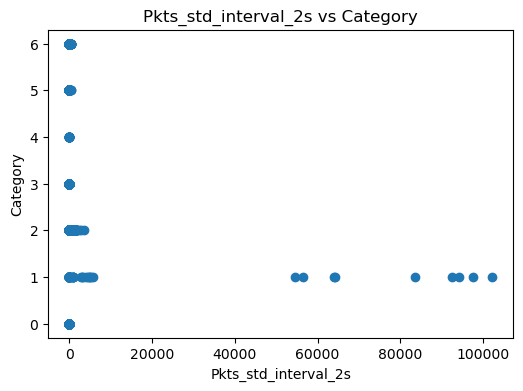

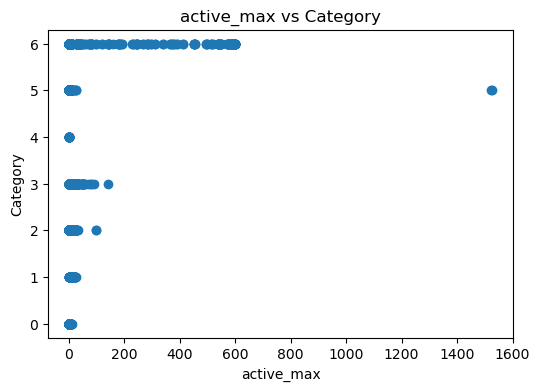

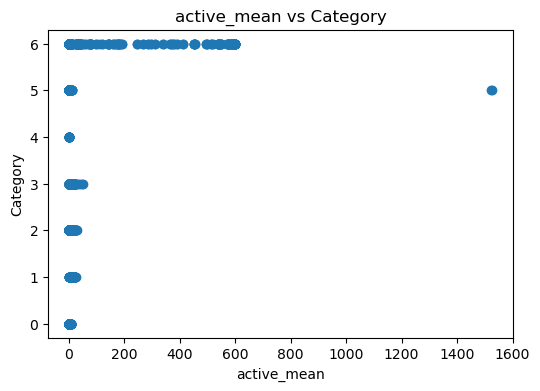

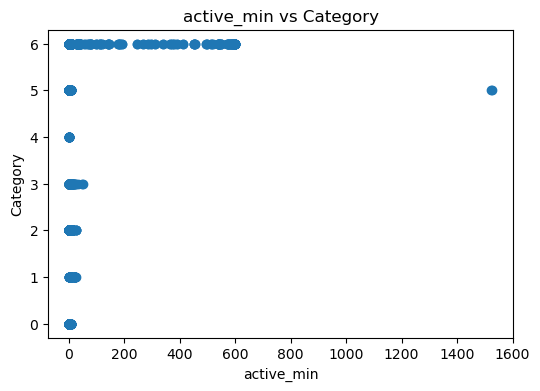

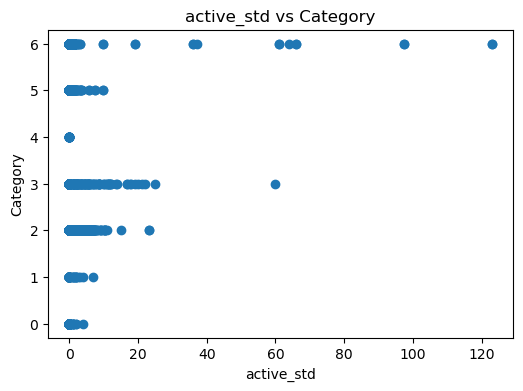

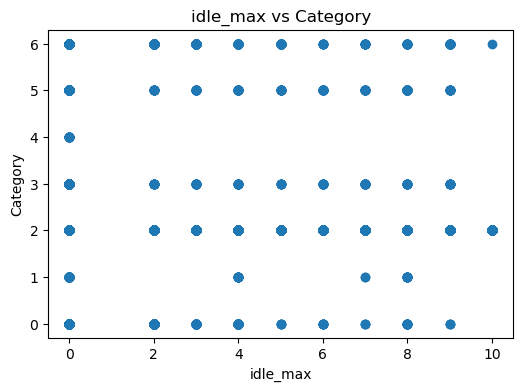

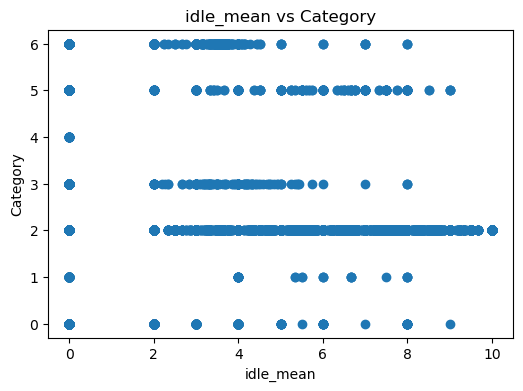

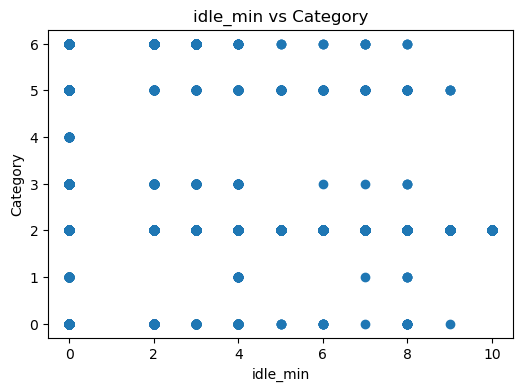

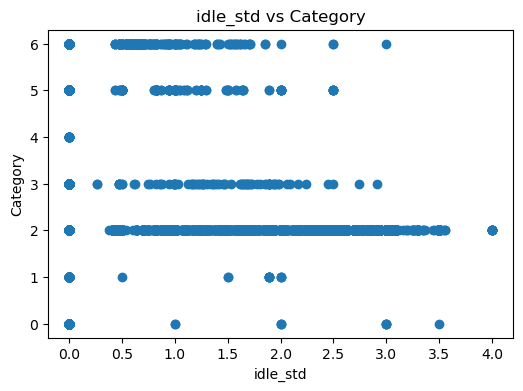

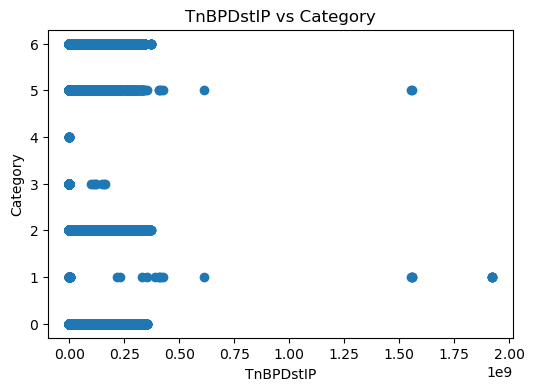

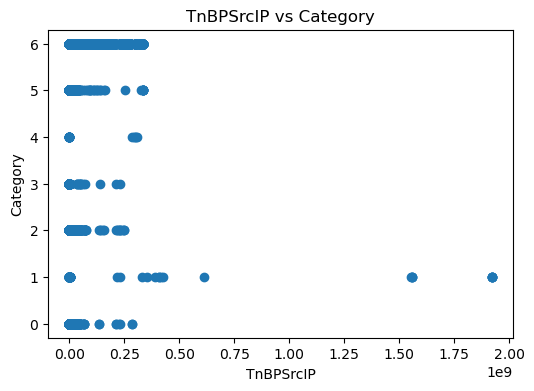

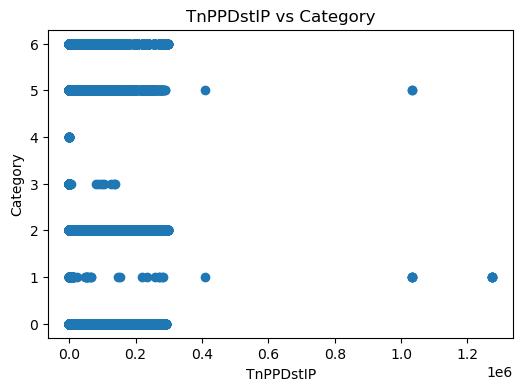

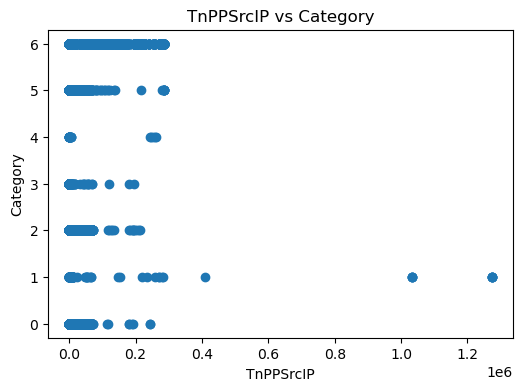

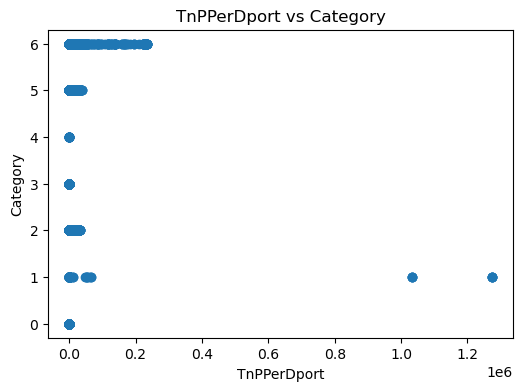

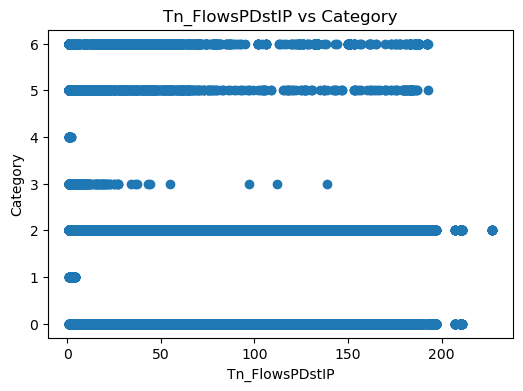

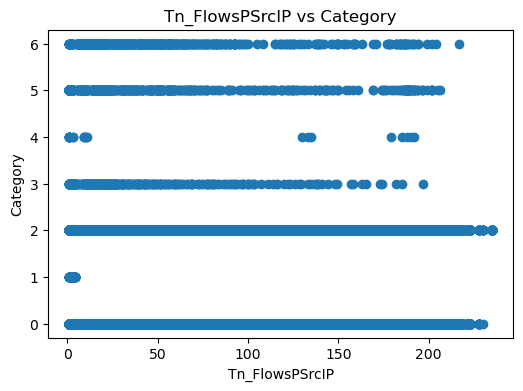

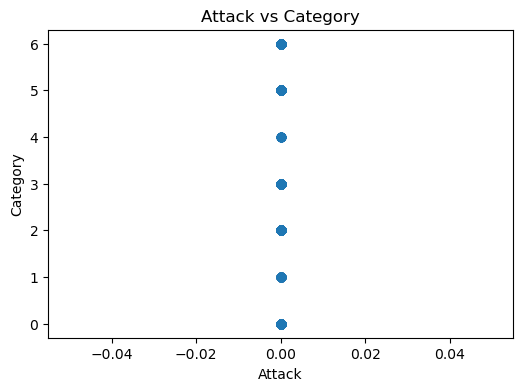

In [333]:
for col in num_cols:
    plt.figure(figsize=(6,4))
    plt.scatter(df2[col], df2[target]) # Accessing data from the DataFrame
    plt.title(f'{col} vs {target}')
    plt.xlabel(col)
    plt.ylabel(target)
    plt.show()

In [334]:

df=df2
import numpy as np
from scipy import stats
outliers = []
for col in num_cols:
    z_scores = stats.zscore(df[col])
    outliers.append(df[np.abs(z_scores) > 3]) # Typically threshold 3 or -3


In [335]:
outliers

[Empty DataFrame
 Columns: [ipv4_src, ipv4_dst, ip_proto, src_port, dst_port, flow_duration, tot_len_pkts, tot_pkts, flow_byts_s, flow_pkts_s, pkt_size_average, fwd_header_len, Byts_max_interval_2s, Byts_min_interval_2s, Byts_mean_interval_2s, Byts_std_interval_2s, Pkts_max_interval_2s, Pkts_mean_interval_2s, Pkts_min_interval_2s, Pkts_std_interval_2s, active_max, active_mean, active_min, active_std, idle_max, idle_mean, idle_min, idle_std, TnBPDstIP, TnBPSrcIP, TnPPDstIP, TnPPSrcIP, TnPPerDport, Tn_FlowsPDstIP, Tn_FlowsPSrcIP, Attack, Category]
 Index: []
 
 [0 rows x 37 columns],
 Empty DataFrame
 Columns: [ipv4_src, ipv4_dst, ip_proto, src_port, dst_port, flow_duration, tot_len_pkts, tot_pkts, flow_byts_s, flow_pkts_s, pkt_size_average, fwd_header_len, Byts_max_interval_2s, Byts_min_interval_2s, Byts_mean_interval_2s, Byts_std_interval_2s, Pkts_max_interval_2s, Pkts_mean_interval_2s, Pkts_min_interval_2s, Pkts_std_interval_2s, active_max, active_mean, active_min, active_std, idle_ma

In [336]:
import pandas as pd

# Convert dictionary to DataFrame
outlier_df = pd.DataFrame(list(outlier_counts.items()), columns=['Feature', 'Outlier_Count'])

# Sort by count (optional, descending)
outlier_df = outlier_df.sort_values(by='Outlier_Count', ascending=False).reset_index(drop=True)

# Display neatly
print(outlier_df)


                  Feature  Outlier_Count
0                idle_max          12952
1                idle_min          10283
2               idle_mean           9478
3        pkt_size_average           5547
4                idle_std           5296
5               TnPPSrcIP           1849
6               TnBPSrcIP            899
7              active_std            694
8           flow_duration            587
9    Byts_min_interval_2s            553
10   Pkts_min_interval_2s            497
11            TnPPerDport            352
12            flow_pkts_s            200
13            flow_byts_s            187
14             active_max            163
15            active_mean            144
16             active_min            143
17               tot_pkts            134
18           tot_len_pkts             77
19         fwd_header_len             75
20  Byts_mean_interval_2s             35
21   Byts_std_interval_2s             32
22  Pkts_mean_interval_2s             31
23   Pkts_std_in

In [337]:
#We are not removing outliers as it is not needed to do for models like xgboost, svm , decision tree etc


In [338]:
df_minmax = df
df_robust = df
df_std = df

In [339]:
from sklearn.preprocessing import StandardScaler , RobustScaler, MinMaxScaler
scaler1 = MinMaxScaler(feature_range=(0, 1))  # scales to [0, 1] by default
df_minmax[num_cols] = scaler1.fit_transform(df_minmax[num_cols])
#scaled_df = df.copy()


In [340]:
df_minmax

,ipv4_src,ipv4_dst,ip_proto,src_port,dst_port,flow_duration,tot_len_pkts,tot_pkts,flow_byts_s,flow_pkts_s,...,idle_std,TnBPDstIP,TnBPSrcIP,TnPPDstIP,TnPPSrcIP,TnPPerDport,Tn_FlowsPDstIP,Tn_FlowsPSrcIP,Attack,Category
0,0.481506,0.481374,0.3125,0.000361,0.678864,0.001914,5.904854e-05,0.000493,0.000342,0.002850,...,0.0,5.904854e-05,0.003797,0.000493,0.005227,0.000493,0.000000,0.038462,0.0,5
1,0.480857,0.482017,0.3125,0.678864,0.000361,0.001912,1.274514e-05,0.000290,0.000074,0.001681,...,0.0,1.357151e-05,0.000013,0.000299,0.000290,0.000290,0.004425,0.000000,0.0,5
2,0.482154,0.482017,0.0000,0.000000,0.000000,0.001419,1.150560e-06,0.000003,0.000009,0.000024,...,0.0,1.472207e-05,0.000002,0.000302,0.000012,0.000000,0.008850,0.004274,0.0,3
3,0.481506,0.482659,1.0000,0.941425,0.020263,0.176089,5.634577e-03,0.020114,0.000354,0.001265,...,0.0,9.833114e-02,0.094072,0.123318,0.120791,0.024130,0.261062,0.076923,0.0,6
4,0.481506,0.482659,1.0000,0.795898,0.020230,0.176083,8.042556e-02,0.090029,0.005060,0.005660,...,0.0,9.833114e-02,0.094072,0.123318,0.120791,0.096269,0.261062,0.076923,0.0,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
221559,0.482154,0.522479,1.0000,0.776996,0.000869,0.000197,0.000000e+00,0.000000,0.000000,0.000000,...,0.0,2.171025e-06,0.000103,0.000021,0.001544,0.000004,0.137168,0.645299,0.0,0
221560,0.482154,0.022800,0.3125,0.713585,0.007262,0.000197,8.627897e-07,0.000010,0.000049,0.000573,...,0.0,1.819248e-06,0.000103,0.000020,0.001544,0.001510,0.004425,0.645299,0.0,2
221561,0.482154,0.218369,0.3125,0.746176,0.007262,0.000196,1.092798e-07,0.000002,0.000006,0.000133,...,0.0,1.092798e-07,0.000103,0.000002,0.001544,0.001510,0.000000,0.645299,0.0,2
221562,0.482154,0.746628,0.3125,0.726241,0.007262,0.000195,0.000000e+00,0.000000,0.000000,0.000000,...,0.0,0.000000e+00,0.000103,0.000000,0.001544,0.001510,0.000000,0.645299,0.0,2


In [341]:
scaler2 = RobustScaler()
scaler3 = StandardScaler()

df_robust[num_cols] = scaler2.fit_transform(df_robust[num_cols])
df_std[num_cols] = scaler3.fit_transform(df_std[num_cols])


In [342]:
df_std.head()

,ipv4_src,ipv4_dst,ip_proto,src_port,dst_port,flow_duration,tot_len_pkts,tot_pkts,flow_byts_s,flow_pkts_s,...,idle_std,TnBPDstIP,TnBPSrcIP,TnPPDstIP,TnPPSrcIP,TnPPerDport,Tn_FlowsPDstIP,Tn_FlowsPSrcIP,Attack,Category
0,0.069852,0.064790,-0.570773,-0.972378,0.735637,0.117953,-0.000929,0.068864,0.041560,0.490216,...,-0.172062,-0.703694,0.326332,-0.706616,0.307010,-0.007669,-0.869341,-0.710465,0.0,5
1,0.066229,0.068355,-0.570773,0.757715,-0.993976,0.117650,-0.008659,0.035332,-0.009644,0.271055,...,-0.172062,-0.704564,-0.072019,-0.709538,-0.118367,-0.037456,-0.853486,-0.844918,0.0,5
2,0.073474,0.068355,-1.622702,-0.973297,-0.994896,0.045639,-0.010594,-0.012236,-0.022041,-0.039485,...,-0.172062,-0.704542,-0.073153,-0.709491,-0.142379,-0.080174,-0.837630,-0.829978,0.0,3
3,0.069852,0.071920,1.743471,1.427212,-0.943243,25.552866,0.929790,3.317934,0.044008,0.192975,...,-0.172062,1.175341,9.830027,1.145127,10.265996,3.469245,0.066143,-0.576012,0.0,6
4,0.069852,0.071920,1.743471,1.056138,-0.943327,25.552046,13.414600,14.895092,0.943524,1.016974,...,-0.172062,1.175341,9.830027,1.145127,10.265996,14.080787,0.066143,-0.576012,0.0,6


In [343]:
df_robust.head()

,ipv4_src,ipv4_dst,ip_proto,src_port,dst_port,flow_duration,tot_len_pkts,tot_pkts,flow_byts_s,flow_pkts_s,...,idle_std,TnBPDstIP,TnBPSrcIP,TnPPDstIP,TnPPSrcIP,TnPPerDport,Tn_FlowsPDstIP,Tn_FlowsPSrcIP,Attack,Category
0,0.069852,0.064790,-0.570773,-0.972378,0.735637,0.117953,-0.000929,0.068864,0.041560,0.490216,...,-0.172062,-0.703694,0.326332,-0.706616,0.307010,-0.007669,-0.869341,-0.710465,0.0,5
1,0.066229,0.068355,-0.570773,0.757715,-0.993976,0.117650,-0.008659,0.035332,-0.009644,0.271055,...,-0.172062,-0.704564,-0.072019,-0.709538,-0.118367,-0.037456,-0.853486,-0.844918,0.0,5
2,0.073474,0.068355,-1.622702,-0.973297,-0.994896,0.045639,-0.010594,-0.012236,-0.022041,-0.039485,...,-0.172062,-0.704542,-0.073153,-0.709491,-0.142379,-0.080174,-0.837630,-0.829978,0.0,3
3,0.069852,0.071920,1.743471,1.427212,-0.943243,25.552866,0.929790,3.317934,0.044008,0.192975,...,-0.172062,1.175341,9.830027,1.145127,10.265996,3.469245,0.066143,-0.576012,0.0,6
4,0.069852,0.071920,1.743471,1.056138,-0.943327,25.552046,13.414600,14.895092,0.943524,1.016974,...,-0.172062,1.175341,9.830027,1.145127,10.265996,14.080787,0.066143,-0.576012,0.0,6


In [344]:
df.head()

,ipv4_src,ipv4_dst,ip_proto,src_port,dst_port,flow_duration,tot_len_pkts,tot_pkts,flow_byts_s,flow_pkts_s,...,idle_std,TnBPDstIP,TnBPSrcIP,TnPPDstIP,TnPPSrcIP,TnPPerDport,Tn_FlowsPDstIP,Tn_FlowsPSrcIP,Attack,Category
0,0.069852,0.064790,-0.570773,-0.972378,0.735637,0.117953,-0.000929,0.068864,0.041560,0.490216,...,-0.172062,-0.703694,0.326332,-0.706616,0.307010,-0.007669,-0.869341,-0.710465,0.0,5
1,0.066229,0.068355,-0.570773,0.757715,-0.993976,0.117650,-0.008659,0.035332,-0.009644,0.271055,...,-0.172062,-0.704564,-0.072019,-0.709538,-0.118367,-0.037456,-0.853486,-0.844918,0.0,5
2,0.073474,0.068355,-1.622702,-0.973297,-0.994896,0.045639,-0.010594,-0.012236,-0.022041,-0.039485,...,-0.172062,-0.704542,-0.073153,-0.709491,-0.142379,-0.080174,-0.837630,-0.829978,0.0,3
3,0.069852,0.071920,1.743471,1.427212,-0.943243,25.552866,0.929790,3.317934,0.044008,0.192975,...,-0.172062,1.175341,9.830027,1.145127,10.265996,3.469245,0.066143,-0.576012,0.0,6
4,0.069852,0.071920,1.743471,1.056138,-0.943327,25.552046,13.414600,14.895092,0.943524,1.016974,...,-0.172062,1.175341,9.830027,1.145127,10.265996,14.080787,0.066143,-0.576012,0.0,6


In [345]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 221564 entries, 0 to 221563
Data columns (total 37 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   ipv4_src               221564 non-null  float64
 1   ipv4_dst               221564 non-null  float64
 2   ip_proto               221564 non-null  float64
 3   src_port               221564 non-null  float64
 4   dst_port               221564 non-null  float64
 5   flow_duration          221564 non-null  float64
 6   tot_len_pkts           221564 non-null  float64
 7   tot_pkts               221564 non-null  float64
 8   flow_byts_s            221564 non-null  float64
 9   flow_pkts_s            221564 non-null  float64
 10  pkt_size_average       221564 non-null  float64
 11  fwd_header_len         221564 non-null  float64
 12  Byts_max_interval_2s   221564 non-null  float64
 13  Byts_min_interval_2s   221564 non-null  float64
 14  Byts_mean_interval_2s  221564 non-nu

In [346]:
df['Category'].value_counts()


Category
2    164974
0     53551
6      1487
5      1133
3       305
1        91
4        23
Name: count, dtype: int64

In [350]:
import numpy as np

values = [164974, 53551, 1487, 1133, 305, 91, 23]
average = np.mean(values)
print(average)


31652.0


In [359]:
target_size = 31652

from sklearn.utils import resample

balanced_dfs = []

for cls in df['Category'].unique():
    cls_df = df[df['Category'] == cls]
    
    if len(cls_df) > target_size:
        # Undersample
        cls_sampled = resample(cls_df, replace=False, n_samples=target_size, random_state=42)
    else:
        # Oversample (with replacement)
        cls_sampled = resample(cls_df, replace=True, n_samples=target_size, random_state=42)
    
    balanced_dfs.append(cls_sampled)

df_balanced = pd.concat(balanced_dfs).reset_index(drop=True)


In [360]:
df.head()


,ipv4_src,ipv4_dst,ip_proto,src_port,dst_port,flow_duration,tot_len_pkts,tot_pkts,flow_byts_s,flow_pkts_s,...,idle_std,TnBPDstIP,TnBPSrcIP,TnPPDstIP,TnPPSrcIP,TnPPerDport,Tn_FlowsPDstIP,Tn_FlowsPSrcIP,Attack,Category
0,0.069852,0.064790,-0.570773,-0.972378,0.735637,0.117953,-0.000929,0.068864,0.041560,0.490216,...,-0.172062,-0.703694,0.326332,-0.706616,0.307010,-0.007669,-0.869341,-0.710465,0.0,5
1,0.066229,0.068355,-0.570773,0.757715,-0.993976,0.117650,-0.008659,0.035332,-0.009644,0.271055,...,-0.172062,-0.704564,-0.072019,-0.709538,-0.118367,-0.037456,-0.853486,-0.844918,0.0,5
2,0.073474,0.068355,-1.622702,-0.973297,-0.994896,0.045639,-0.010594,-0.012236,-0.022041,-0.039485,...,-0.172062,-0.704542,-0.073153,-0.709491,-0.142379,-0.080174,-0.837630,-0.829978,0.0,3
3,0.069852,0.071920,1.743471,1.427212,-0.943243,25.552866,0.929790,3.317934,0.044008,0.192975,...,-0.172062,1.175341,9.830027,1.145127,10.265996,3.469245,0.066143,-0.576012,0.0,6
4,0.069852,0.071920,1.743471,1.056138,-0.943327,25.552046,13.414600,14.895092,0.943524,1.016974,...,-0.172062,1.175341,9.830027,1.145127,10.265996,14.080787,0.066143,-0.576012,0.0,6


In [362]:
df_balanced['Category'].value_counts()


Category
5    31652
3    31652
6    31652
0    31652
2    31652
1    31652
4    31652
Name: count, dtype: int64